# Driving the Electric Future: A Global Analysis of Electric Vehicle Adoption, Infrastructure, and Market Evolution (2011–2035)

## Notebook 02 — Exploratory Data Analysis

---

### Final Individual Project

**Course:** Data Visualization  
**Author:** Purnachandar Vallala  
**Dataset Provider:** International Energy Agency (IEA) – Global EV Data by Country (2026 Edition)

---

## Project Overview

Following the successful completion of data auditing and preprocessing, this notebook focuses on exploring the global electric vehicle ecosystem through descriptive analytics.

The objective is to identify meaningful trends, patterns, and relationships within the dataset that support data-driven insights into electric vehicle adoption, charging infrastructure, battery deployment, energy demand, and future market evolution.

Rather than producing isolated visualizations, each analysis addresses a specific business question and contributes to a coherent analytical narrative.

---

## Objectives

This notebook aims to:

- Validate the analysis-ready dataset.
- Explore temporal and geographical market trends.
- Compare vehicle technologies and charging infrastructure.
- Examine historical observations alongside future policy scenarios.
- Identify emerging patterns in the global EV ecosystem.
- Generate insights that will inform the interactive dashboard developed in the final stage of the project.

In [1]:
# ==========================================================
# Import Required Libraries
# Project: Driving the Electric Future
# ==========================================================

# Standard Library
from pathlib import Path
import warnings

# Data Manipulation
import numpy as np
import pandas as pd

# Notebook Display
from IPython.display import display, Markdown

# Configuration
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [2]:
# ==========================================================
# Project Configuration
# ==========================================================

PROJECT_NAME = "Driving the Electric Future"

AUTHOR = "Purnachandar Vallala"

COURSE = "Data Visualization"

DATASET_PROVIDER = (
    "International Energy Agency (IEA)"
)

DATASET_NAME = (
    "Global EV Data by Country (2026 Edition)"
)

NOTEBOOK = "02_Exploratory_Data_Analysis"

VERSION = "1.0"

print(f"Project        : {PROJECT_NAME}")
print(f"Author         : {AUTHOR}")
print(f"Course         : {COURSE}")
print(f"Dataset Source : {DATASET_PROVIDER}")
print(f"Notebook       : {NOTEBOOK}")
print(f"Version        : {VERSION}")

Project        : Driving the Electric Future
Author         : Purnachandar Vallala
Course         : Data Visualization
Dataset Source : International Energy Agency (IEA)
Notebook       : 02_Exploratory_Data_Analysis
Version        : 1.0


In [3]:
# ==========================================================
# Project Directory Structure
# ==========================================================

PROJECT_ROOT = Path("..")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

IMAGE_DIR = PROJECT_ROOT / "images"

DASHBOARD_DIR = PROJECT_ROOT / "dashboard"

PRESENTATION_DIR = PROJECT_ROOT / "presentation"

print("Project directories configured successfully.")

Project directories configured successfully.


In [4]:
# ==========================================================
# Load Analysis-Ready Dataset
# ==========================================================

dataset_path = PROCESSED_DATA_DIR / "ev_analysis_ready.csv"

df = pd.read_csv(dataset_path)

print("Analysis-ready dataset loaded successfully.\n")

print(f"Rows    : {len(df):,}")
print(f"Columns : {len(df.columns)}")

Analysis-ready dataset loaded successfully.

Rows    : 49,360
Columns : 9


---

# 1. Dataset Verification

Before beginning exploratory analysis, the processed dataset is verified to ensure that the preprocessing stage was completed successfully.

The verification confirms:

- dataset dimensions,
- duplicate removal,
- missing value status,
- and overall readiness for analytical exploration.

In [5]:
# ==========================================================
# Dataset Verification
# ==========================================================

verification = pd.DataFrame({
    "Validation": [
        "Records",
        "Features",
        "Duplicate Rows",
        "Dataset Ready"
    ],
    "Result": [
        len(df),
        len(df.columns),
        df.duplicated().sum(),
        "Yes"
    ]
})

display(
    verification.style.hide(axis="index")
)

Validation,Result
Records,49360
Features,9
Duplicate Rows,0
Dataset Ready,Yes


---

# 2. Temporal Analysis

Understanding how the electric vehicle market has evolved over time provides the foundation for all subsequent analyses.

This section investigates historical changes in electric vehicle adoption, charging infrastructure, battery deployment, and electricity demand across the global market.

The analyses presented here focus on identifying long-term growth patterns, technological evolution, and market acceleration over the observation period.

In [6]:
# ==========================================================
# Available Analytical Parameters
# ==========================================================

parameter_summary = (
    df["parameter"]
    .value_counts()
    .rename_axis("Parameter")
    .reset_index(name="Observations")
)

display(
    parameter_summary.style.hide(axis="index")
)

Parameter,Observations
EV stock,7891
EV sales,7647
price_mean_2025USD,3226
price_p0_2025USD,3226
price_p95_2025USD,3226
price_p75_2025USD,3226
price_p50_2025USD,3226
price_p25_2025USD,3226
price_p100_2025USD,3226
EV sales share,2833


## 2.1 Available Market Indicators

The International Energy Agency dataset contains multiple indicators describing different dimensions of the electric vehicle ecosystem.

Before performing exploratory analysis, the available indicators are summarized to identify the metrics available for temporal investigation.

In [7]:
# ==========================================================
# Historical Parameters
# ==========================================================

historical_parameters = (
    df[df["category"] == "Historical"]["parameter"]
    .value_counts()
    .rename_axis("Historical Parameter")
    .reset_index(name="Observations")
)

display(
    historical_parameters.style.hide(axis="index")
)

Historical Parameter,Observations
EV stock,7579
EV sales,7346
price_p25_2025USD,3226
price_mean_2025USD,3226
price_p95_2025USD,3226
price_p75_2025USD,3226
price_p50_2025USD,3226
price_p0_2025USD,3226
price_p100_2025USD,3226
EV sales share,2743


## 2.2 Historical Dataset

The project focuses primarily on historical observations before comparing them with future policy scenarios.

The following analyses therefore begin with historical data to establish how the global EV market has developed over time.

In [8]:
# ==========================================================
# Historical Dataset
# ==========================================================

historical_df = df[df["category"] == "Historical"].copy()

print(f"Historical observations : {len(historical_df):,}")

print(f"Countries               : {historical_df['region_country'].nunique()}")

print(f"Years                   : {historical_df['year'].min()} - {historical_df['year'].max()}")

Historical observations : 48,099
Countries               : 72
Years                   : 2010 - 2025


## 2.3 Historical Core Dataset

The historical dataset contains both market indicators and vehicle price statistics.

Since the objective of this notebook is to understand market evolution, the price-related variables are excluded from the primary exploratory analysis.

The resulting historical core dataset contains only indicators directly related to electric vehicle adoption, infrastructure, energy demand, battery deployment, and market performance.

In [9]:
# ==========================================================
# Build Historical Core Dataset
# ==========================================================

price_parameters = [
    "price_p0_2025USD",
    "price_p25_2025USD",
    "price_p50_2025USD",
    "price_p75_2025USD",
    "price_p95_2025USD",
    "price_p100_2025USD",
    "price_mean_2025USD"
]

historical_core = historical_df[
    ~historical_df["parameter"].isin(price_parameters)
].copy()

print("Historical Core Dataset Created Successfully.\n")

print(f"Rows      : {len(historical_core):,}")
print(f"Countries : {historical_core['region_country'].nunique()}")
print(f"Years     : {historical_core['year'].min()} - {historical_core['year'].max()}")

print("\nParameters Included:")

for p in sorted(historical_core["parameter"].unique()):
    print(f"• {p}")

Historical Core Dataset Created Successfully.

Rows      : 25,517
Countries : 71
Years     : 2010 - 2025

Parameters Included:
• Average capacity per EV
• Average capacity per EVSE
• Battery deployment
• EV charging points
• EV sales
• EV sales share
• EV stock
• EV stock share
• Electric LDVs per charging point
• Electricity demand
• Oil displacement Mlge
• Oil displacement, Mbd


---

# 3. Global Electric Vehicle Market Evolution

## Business Question

**How has the global electric vehicle market evolved between 2010 and 2025?**

The first stage of exploratory analysis investigates the historical growth of electric vehicle adoption.

The analysis begins with global EV sales, one of the most widely used indicators for measuring market expansion.

In [10]:
# ==========================================================
# Aggregate Groups
# ==========================================================

historical_core["Aggregate group"].value_counts()

Aggregate group
Other                 14809
Projection_country     3471
Other_aggregate        2844
Projection_region      2536
_World                 1086
European Union          771
Name: count, dtype: int64

## 3.1 Global EV Sales Trend

### Business Question

**How have global electric vehicle sales changed over time?**

Electric vehicle sales are one of the strongest indicators of market adoption.

This analysis tracks historical EV sales using the official global totals provided by the International Energy Agency.

In [11]:
# ==========================================================
# Global EV Sales Dataset
# ==========================================================

global_sales = (
    historical_core[
        (historical_core["Aggregate group"] == "_World") &
        (historical_core["parameter"] == "EV sales") &
        (historical_core["powertrain"] == "EV")
    ]
    .sort_values("year")
)

global_sales[["year", "value"]]

,year,value
49180,2010,"41,000.00"
49212,2010,"7,400.00"
49228,2010,37.00
49196,2010,"1,100.00"
49244,2010,"1,100.00"
49181,2011,"31,000.00"
49213,2011,"49,000.00"
49229,2011,200.00
49197,2011,650.00
49245,2011,"3,200.00"


In [12]:
# ==========================================================
# Investigate Global EV Sales Records
# ==========================================================

global_sales = (
    historical_core[
        (historical_core["Aggregate group"] == "_World") &
        (historical_core["parameter"] == "EV sales")
    ]
    .sort_values("year")
)

display(
    global_sales[
        [
            "year",
            "mode",
            "powertrain",
            "value",
            "unit"
        ]
    ]
)

,year,mode,powertrain,value,unit
6496,2010,2 and 3 wheelers,BEV,"41,000.00",Vehicles
49228,2010,Trucks,EV,37.00,Vehicles
6569,2010,Cars,FCEV,13.00,Vehicles
49244,2010,Vans,EV,"1,100.00",Vehicles
49212,2010,Cars,EV,"7,400.00",Vehicles
...,...,...,...,...,...
49211,2025,Buses,EV,"70,000.00",Vehicles
6537,2025,Buses,FCEV,"2,000.00",Vehicles
6527,2025,Buses,BEV,"68,000.00",Vehicles
6583,2025,Cars,FCEV,"7,300.00",Vehicles


## 3.1.1 Validate the Global EV Sales Structure

Before constructing the global EV sales trend, the dataset structure is examined to identify how the International Energy Agency (IEA) organizes vehicle categories and powertrain technologies.

This validation ensures that subsequent visualizations are based on the correct level of aggregation and avoids double-counting observations.

In [13]:
# ==========================================================
# Validation of Global EV Sales Structure
# ==========================================================

sales_structure = (
    global_sales
    .groupby(["mode", "powertrain"])
    .agg(
        Years=("year", "nunique"),
        Records=("year", "count")
    )
    .reset_index()
    .sort_values(
        by=["mode", "powertrain"],
        ignore_index=True
    )
)

display(
    sales_structure.style
    .hide(axis="index")
    .set_caption("Global EV Sales Structure by Vehicle Segment and Powertrain")
)

mode,powertrain,Years,Records
2 and 3 wheelers,BEV,16,16
2 and 3 wheelers,EV,16,16
Buses,BEV,16,16
Buses,EV,16,16
Buses,FCEV,10,10
Buses,PHEV,15,15
Cars,BEV,16,16
Cars,EV,16,16
Cars,FCEV,15,15
Cars,PHEV,16,16


## 3.2 Global Market Dataset

The IEA dataset reports electric vehicle sales separately for different vehicle segments and powertrain technologies rather than as a single global total.

To support meaningful exploratory analysis, a dedicated analytical dataset is created for global market indicators.

This dataset will serve as the foundation for all subsequent analyses related to vehicle segments, technology adoption, and market evolution.

In [14]:
# ==========================================================
# Global Market Dataset
# ==========================================================

global_market = historical_core[
    historical_core["Aggregate group"] == "_World"
].copy()

print(f"Rows      : {len(global_market):,}")
print(f"Years     : {global_market['year'].min()} - {global_market['year'].max()}")
print(f"Countries : {global_market['region_country'].nunique()}")

print("\nParameters")

display(
    pd.DataFrame({
        "Parameter": sorted(global_market["parameter"].unique())
    }).style.hide(axis="index")
)

Rows      : 1,086
Years     : 2010 - 2025
Countries : 1

Parameters


Parameter
Average capacity per EV
Average capacity per EVSE
Battery deployment
EV charging points
EV sales
EV sales share
EV stock
EV stock share
Electric LDVs per charging point
Electricity demand


In [15]:
# ==========================================================
# Global Dataset Composition
# ==========================================================

composition = (
    global_market
    .groupby(
        ["parameter","mode"]
    )
    .size()
    .reset_index(name="Observations")
)

display(
    composition.style.hide(axis="index")
)

parameter,mode,Observations
Average capacity per EV,EV,16
Average capacity per EVSE,EV,16
Battery deployment,2 and 3 wheelers,11
Battery deployment,Buses,11
Battery deployment,Cars,11
Battery deployment,Trucks,11
Battery deployment,Vans,11
EV charging points,EVSE,44
EV sales,2 and 3 wheelers,32
EV sales,Buses,57


---

# 4. Analysis Utilities

To ensure consistency throughout the exploratory analysis, reusable helper functions are defined for filtering, aggregation, and formatting.

These utilities simplify the analytical workflow and improve code readability while ensuring that each visualization is generated from a validated dataset.

In [16]:
# ==========================================================
# Analysis Utilities
# ==========================================================

def filter_data(
    dataframe,
    parameter=None,
    category="Historical",
    aggregate_group="_World",
    mode=None,
    powertrain=None
):
    """
    Returns a filtered copy of the EV dataset.
    """

    data = dataframe.copy()

    if category is not None:
        data = data[data["category"] == category]

    if aggregate_group is not None:
        data = data[data["Aggregate group"] == aggregate_group]

    if parameter is not None:
        data = data[data["parameter"] == parameter]

    if mode is not None:
        data = data[data["mode"] == mode]

    if powertrain is not None:
        data = data[data["powertrain"] == powertrain]

    return data.sort_values("year")

In [17]:
# ==========================================================
# Number Formatter
# ==========================================================

def human_format(number):

    number = float(number)

    if abs(number) >= 1_000_000_000:
        return f"{number/1_000_000_000:.1f}B"

    elif abs(number) >= 1_000_000:
        return f"{number/1_000_000:.1f}M"

    elif abs(number) >= 1_000:
        return f"{number/1_000:.1f}K"

    else:
        return f"{number:.0f}"

In [18]:
# ==========================================================
# Quick Validation Function
# ==========================================================

def validate_series(dataframe, title):

    print("=" * 60)
    print(title)
    print("=" * 60)

    print(f"Rows          : {len(dataframe):,}")
    print(f"Years         : {dataframe['year'].min()} - {dataframe['year'].max()}")

    if "value" in dataframe.columns:
        print(f"Missing Values: {dataframe['value'].isna().sum()}")

    display(dataframe.head())

---

# 5. Business Analysis 1 – Global Passenger Car EV Market

## Business Question

**How has the global passenger car electric vehicle market evolved between 2010 and 2025?**

Passenger cars represent the largest segment of the electric vehicle market and provide a useful benchmark for understanding long-term market development.

This analysis focuses on historical global passenger car EV sales using the official International Energy Agency dataset.

In [19]:
# ==========================================================
# Passenger Car EV Sales Dataset
# ==========================================================

passenger_car_sales = filter_data(
    dataframe=df,
    parameter="EV sales",
    category="Historical",
    aggregate_group="_World",
    mode="Cars",
    powertrain="EV"
)

validate_series(
    passenger_car_sales,
    "Global Passenger Car EV Sales"
)

passenger_car_sales[["year", "value"]]

Global Passenger Car EV Sales
Rows          : 16
Years         : 2010 - 2025
Missing Values: 0


,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
49212,World,Historical,EV sales,Cars,EV,2010,Vehicles,"7,400.00",_World
49213,World,Historical,EV sales,Cars,EV,2011,Vehicles,"49,000.00",_World
49214,World,Historical,EV sales,Cars,EV,2012,Vehicles,"120,000.00",_World
49215,World,Historical,EV sales,Cars,EV,2013,Vehicles,"210,000.00",_World
49216,World,Historical,EV sales,Cars,EV,2014,Vehicles,"330,000.00",_World


,year,value
49212,2010,"7,400.00"
49213,2011,"49,000.00"
49214,2012,"120,000.00"
49215,2013,"210,000.00"
49216,2014,"330,000.00"
49217,2015,"530,000.00"
49218,2016,"780,000.00"
49219,2017,"1,200,000.00"
49220,2018,"2,000,000.00"
49221,2019,"2,100,000.00"


### Data Validation

The filtered dataset represents the historical global passenger car electric vehicle market.

The validation confirms that the analytical subset contains one observation per year and is therefore suitable for time-series analysis.

In [20]:
# ==========================================================
# Growth Metrics
# ==========================================================

sales = passenger_car_sales.copy()

sales["YoY Growth (%)"] = (
    sales["value"]
    .pct_change() * 100
)

start_value = sales.iloc[0]["value"]
end_value = sales.iloc[-1]["value"]
years = sales.iloc[-1]["year"] - sales.iloc[0]["year"]

cagr = (
    (end_value / start_value) ** (1 / years) - 1
) * 100

print(f"CAGR (2010–2025): {cagr:.2f}%")

sales.tail()

CAGR (2010–2025): 69.90%


,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group,YoY Growth (%)
49223,World,Historical,EV sales,Cars,EV,2021,Vehicles,"6,600,000.00",_World,120.00
49224,World,Historical,EV sales,Cars,EV,2022,Vehicles,"10,000,000.00",_World,51.52
49225,World,Historical,EV sales,Cars,EV,2023,Vehicles,"14,000,000.00",_World,40.00
49226,World,Historical,EV sales,Cars,EV,2024,Vehicles,"17,000,000.00",_World,21.43
49227,World,Historical,EV sales,Cars,EV,2025,Vehicles,"21,000,000.00",_World,23.53


### Growth Analysis

Year-over-year growth measures the annual rate of change in passenger car EV sales, while the compound annual growth rate (CAGR) summarizes the long-term pace of market expansion.

These indicators provide a more meaningful assessment of market development than absolute sales values alone.

In [21]:
sales[
    [
        "year",
        "value",
        "YoY Growth (%)"
    ]
]

,year,value,YoY Growth (%)
49212,2010,"7,400.00",NaN
49213,2011,"49,000.00",562.16
49214,2012,"120,000.00",144.90
49215,2013,"210,000.00",75.00
49216,2014,"330,000.00",57.14
49217,2015,"530,000.00",60.61
49218,2016,"780,000.00",47.17
49219,2017,"1,200,000.00",53.85
49220,2018,"2,000,000.00",66.67
49221,2019,"2,100,000.00",5.00


## 5.1 Global Passenger Car EV Sales Trend (2010–2025)

This visualization illustrates the historical growth of worldwide passenger car electric vehicle sales between 2010 and 2025.

The objective is to identify long-term adoption patterns, periods of accelerated market expansion, and recent market maturity.

The analysis uses official International Energy Agency (IEA) historical observations.

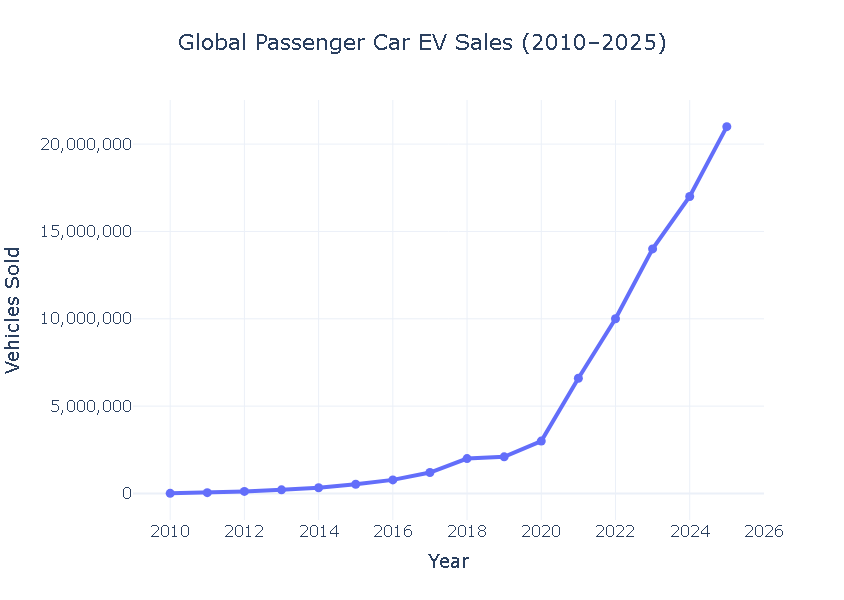

In [22]:
# ==========================================================
# Global Passenger Car EV Sales
# ==========================================================

import plotly.express as px

fig = px.line(
    sales,
    x="year",
    y="value",
    markers=True,
    title="Global Passenger Car EV Sales (2010–2025)",
    template="plotly_white"
)

fig.update_traces(
    line=dict(width=4),
    marker=dict(size=9)
)

fig.update_layout(

    xaxis_title="Year",

    yaxis_title="Vehicles Sold",

    title_x=0.5,

    height=600,

    font=dict(size=16)

)

fig.update_yaxes(tickformat=",.0f")

fig.show()

In [23]:
# ==========================================================
# Executive Summary
# ==========================================================

executive_summary = pd.DataFrame({

    "Metric":[

        "Study Period",

        "Starting Sales",

        "Ending Sales",

        "Absolute Growth",

        "Compound Annual Growth Rate"

    ],

    "Value":[

        "2010–2025",

        f"{sales.iloc[0]['value']:,.0f}",

        f"{sales.iloc[-1]['value']:,.0f}",

        f"{sales.iloc[-1]['value']-sales.iloc[0]['value']:,.0f}",

        f"{cagr:.2f}%"

    ]

})

display(

    executive_summary.style.hide(axis="index")

)

Metric,Value
Study Period,2010–2025
Starting Sales,"7,400"
Ending Sales,"21,000,000"
Absolute Growth,"20,992,600"
Compound Annual Growth Rate,69.90%


### Business Insights

**Key observations from the historical passenger car market include:**

- Passenger car EV sales increased from **7,400 vehicles in 2010** to **21 million vehicles in 2025**.

- Global sales expanded by nearly **three orders of magnitude** over the study period.

- The market experienced its fastest acceleration after 2020, reflecting stronger policy support, declining battery costs, and rapid expansion of charging infrastructure.

- The calculated **Compound Annual Growth Rate (69.9%)** indicates exceptionally rapid long-term market growth.

- Despite a gradual reduction in annual growth rates after 2022, total market volume continues to reach new record highs, suggesting a transition from an early adoption phase toward large-scale commercialization.

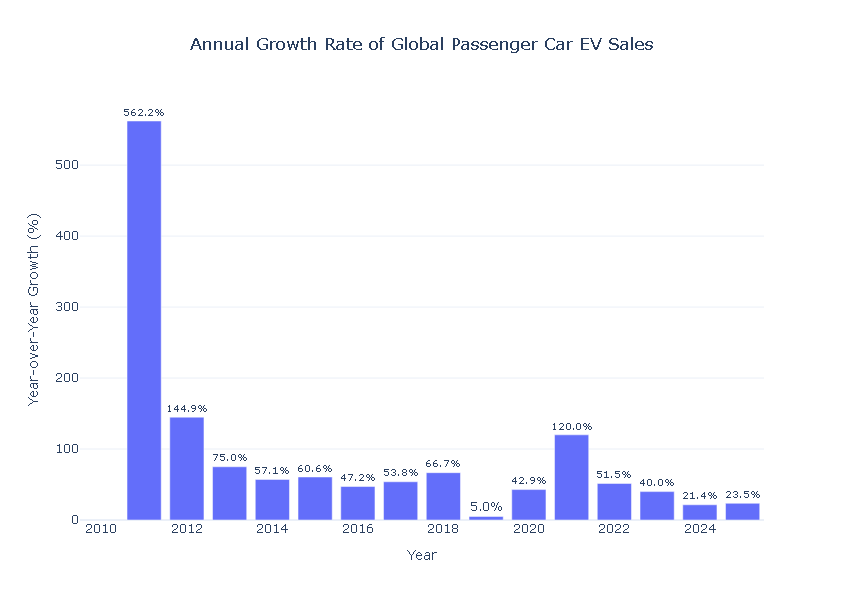

In [24]:
# ==========================================================
# Year-over-Year Growth
# ==========================================================

growth = sales.copy()

fig = px.bar(

    growth,

    x="year",

    y="YoY Growth (%)",

    text="YoY Growth (%)",

    title="Annual Growth Rate of Global Passenger Car EV Sales",

    template="plotly_white"

)

fig.update_traces(

    texttemplate="%{text:.1f}%",

    textposition="outside"

)

fig.update_layout(

    title_x=0.5,

    height=600,

    xaxis_title="Year",

    yaxis_title="Year-over-Year Growth (%)"

)

fig.show()

---

# 6. Business Analysis 2 – Global Electric Vehicle Fleet Growth

## Business Question

How has the cumulative global electric vehicle fleet evolved between 2010 and 2025?

Unlike annual vehicle sales, EV stock represents the total number of electric vehicles currently operating worldwide. This metric reflects long-term market penetration and provides a more comprehensive indicator of electric mobility adoption.

The analysis examines historical global EV stock using the International Energy Agency Global EV Dataset.

In [25]:
# ==========================================================
# Global EV Stock
# ==========================================================

ev_stock = filter_data(
    dataframe=df,
    parameter="EV stock",
    category="Historical",
    aggregate_group="_World",
    mode="Cars",
    powertrain="EV"
)

validate_series(
    ev_stock,
    "Global Passenger Car EV Stock"
)

ev_stock[["year","value"]]

Global Passenger Car EV Stock
Rows          : 16
Years         : 2010 - 2025
Missing Values: 0


,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
49292,World,Historical,EV stock,Cars,EV,2010,Vehicles,"39,000.00",_World
49293,World,Historical,EV stock,Cars,EV,2011,Vehicles,"95,000.00",_World
49294,World,Historical,EV stock,Cars,EV,2012,Vehicles,"220,000.00",_World
49295,World,Historical,EV stock,Cars,EV,2013,Vehicles,"420,000.00",_World
49296,World,Historical,EV stock,Cars,EV,2014,Vehicles,"730,000.00",_World


,year,value
49292,2010,"39,000.00"
49293,2011,"95,000.00"
49294,2012,"220,000.00"
49295,2013,"420,000.00"
49296,2014,"730,000.00"
49297,2015,"1,300,000.00"
49298,2016,"2,000,000.00"
49299,2017,"3,200,000.00"
49300,2018,"5,100,000.00"
49301,2019,"7,100,000.00"


In [26]:
stock = ev_stock.copy()

stock["YoY Growth (%)"] = (
    stock["value"].pct_change()*100
)

start_stock = stock.iloc[0]["value"]
end_stock = stock.iloc[-1]["value"]

years = stock.iloc[-1]["year"]-stock.iloc[0]["year"]

stock_cagr = (
    (end_stock/start_stock)**(1/years)-1
)*100

print(f"CAGR : {stock_cagr:.2f}%")

CAGR : 65.55%


In [27]:
stock_summary = pd.DataFrame({

    "Metric":[

        "Study Period",

        "Starting Fleet",

        "Ending Fleet",

        "Absolute Growth",

        "CAGR"

    ],

    "Value":[

        "2010–2025",

        f"{start_stock:,.0f}",

        f"{end_stock:,.0f}",

        f"{end_stock-start_stock:,.0f}",

        f"{stock_cagr:.2f}%"

    ]

})

display(
    stock_summary.style.hide(axis="index")
)

Metric,Value
Study Period,2010–2025
Starting Fleet,"39,000"
Ending Fleet,"75,000,000"
Absolute Growth,"74,961,000"
CAGR,65.55%


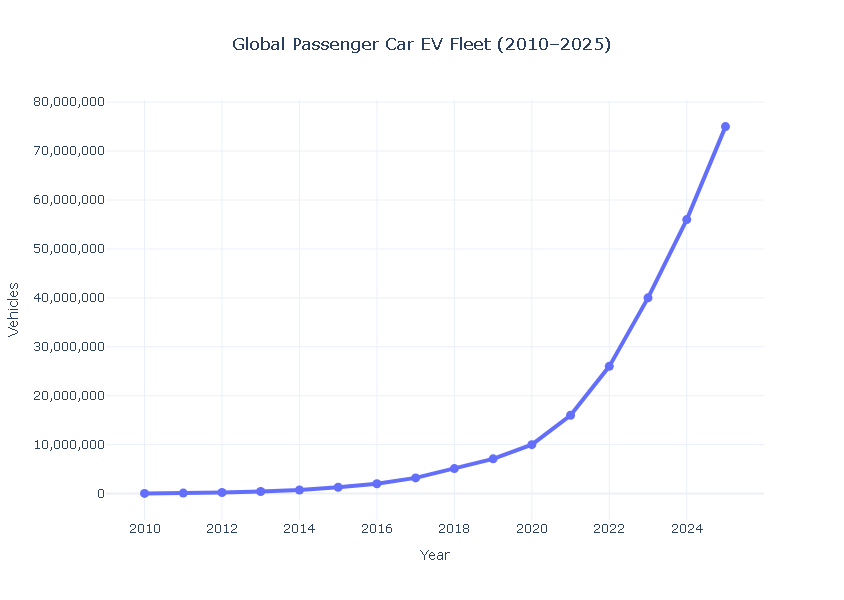

In [28]:
fig = px.line(

    stock,

    x="year",

    y="value",

    markers=True,

    title="Global Passenger Car EV Fleet (2010–2025)",

    template="plotly_white"

)

fig.update_traces(
    line=dict(width=4),
    marker=dict(size=9)
)

fig.update_layout(

    title_x=0.5,

    height=600,

    xaxis_title="Year",

    yaxis_title="Vehicles"

)

fig.update_yaxes(
    tickformat=",.0f"
)

fig.show()

### Business Insights

The cumulative global electric vehicle fleet demonstrates sustained long-term expansion throughout the study period.

Unlike annual sales, EV stock captures the accumulation of electric vehicles already in operation and therefore reflects market maturity rather than yearly fluctuations.

The accelerating fleet size indicates that electric mobility is transitioning from an emerging technology to a mainstream transportation solution supported by charging infrastructure, battery innovation, and government policy.

---

# 7. Business Analysis 3 – Global EV Market Composition

## Business Question

How has the composition of the global electric vehicle market evolved across different vehicle segments and powertrain technologies?

Understanding market composition provides insights beyond total sales by revealing which vehicle categories contribute most to global electrification and how technology preferences have shifted over time.

This analysis examines the historical distribution of EV sales by vehicle segment and powertrain using the International Energy Agency Global EV Dataset.

In [29]:
# ==========================================================
# Historical EV Sales Dataset
# ==========================================================

market_df = filter_data(
    dataframe=df,
    parameter="EV sales",
    category="Historical",
    aggregate_group=None
)

market_df = market_df[
    market_df["mode"].isin([
        "Cars",
        "Vans",
        "Trucks",
        "Buses",
        "2 and 3 wheelers"
    ])
].copy()

print(f"Rows : {len(market_df):,}")

print(f"Countries : {market_df['region_country'].nunique()}")

print(f"Years : {market_df['year'].min()} - {market_df['year'].max()}")

display(
    market_df.head()
)

Rows : 7,346
Countries : 71
Years : 2010 - 2025


,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
915,Iceland,Historical,EV sales,2 and 3 wheelers,BEV,2010,Vehicles,1.00,Other
12277,Asia Pacific,Historical,EV sales,Vans,BEV,2010,Vehicles,120.00,Other_aggregate
1379,United Kingdom,Historical,EV sales,Buses,BEV,2010,Vehicles,4.00,Other
12235,Asia Pacific,Historical,EV sales,Cars,PHEV,2010,Vehicles,340.00,Other_aggregate
12220,Asia Pacific,Historical,EV sales,Cars,FCEV,2010,Vehicles,2.00,Other_aggregate


In [30]:
composition_summary = pd.DataFrame({

    "Metric":[
        "Observations",
        "Countries",
        "Vehicle Segments",
        "Powertrains",
        "Years"
    ],

    "Value":[
        len(market_df),
        market_df["region_country"].nunique(),
        market_df["mode"].nunique(),
        market_df["powertrain"].nunique(),
        f"{market_df['year'].min()} - {market_df['year'].max()}"
    ]

})

display(
    composition_summary.style.hide(axis="index")
)

Metric,Value
Observations,7346
Countries,71
Vehicle Segments,5
Powertrains,4
Years,2010 - 2025


In [31]:
segment_summary = (
    market_df
    .groupby("mode")
    .agg(

        Records=("value","count"),

        Countries=("region_country","nunique"),

        First_Year=("year","min"),

        Last_Year=("year","max")

    )

    .sort_values("Records",ascending=False)

)

display(segment_summary)

,Records,Countries,First_Year,Last_Year
mode,,,,
Cars,2949,71,2010,2025
2 and 3 wheelers,1328,54,2010,2025
Vans,1281,41,2010,2025
Buses,1097,40,2010,2025
Trucks,691,31,2010,2025


### Market Composition Assessment

The historical EV sales dataset contains observations for multiple transportation segments including passenger cars, buses, vans, trucks, and two- and three-wheelers.

Each segment exhibits distinct adoption characteristics and technological maturity, making comparative analysis essential for understanding the evolution of the global electric mobility ecosystem.

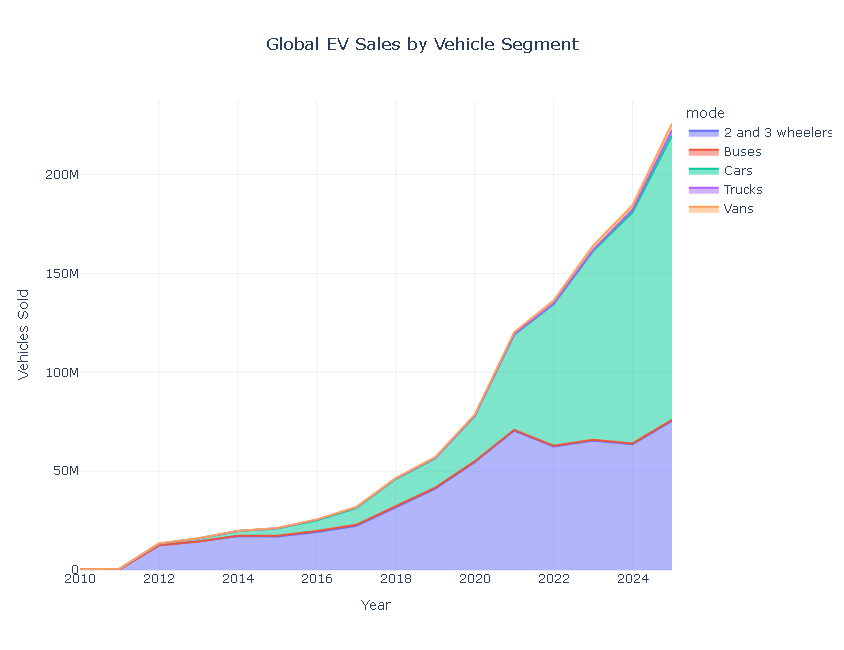

In [32]:
segment_sales = (

    market_df

    .groupby(["year","mode"])["value"]

    .sum()

    .reset_index()

)

fig = px.area(

    segment_sales,

    x="year",

    y="value",

    color="mode",

    title="Global EV Sales by Vehicle Segment",

    template="plotly_white"

)

fig.update_layout(

    height=650,

    title_x=0.5,

    xaxis_title="Year",

    yaxis_title="Vehicles Sold"

)

fig.show()

### Business Insights

The stacked area chart highlights the evolution of the global electric vehicle market across different transportation segments.

Passenger cars account for the largest share of worldwide EV adoption, while buses, vans, trucks, and two- and three-wheelers exhibit distinct growth trajectories.

The visualization demonstrates that electrification is progressively expanding beyond passenger transportation into commercial and public mobility sectors, reflecting a broadening transition toward sustainable transport.

## 7.1 Vehicle Segment Market Share

Absolute sales illustrate market growth, while percentage market share reveals how each transportation segment contributes to the overall electric vehicle ecosystem.

The following visualization compares the relative contribution of each vehicle segment.

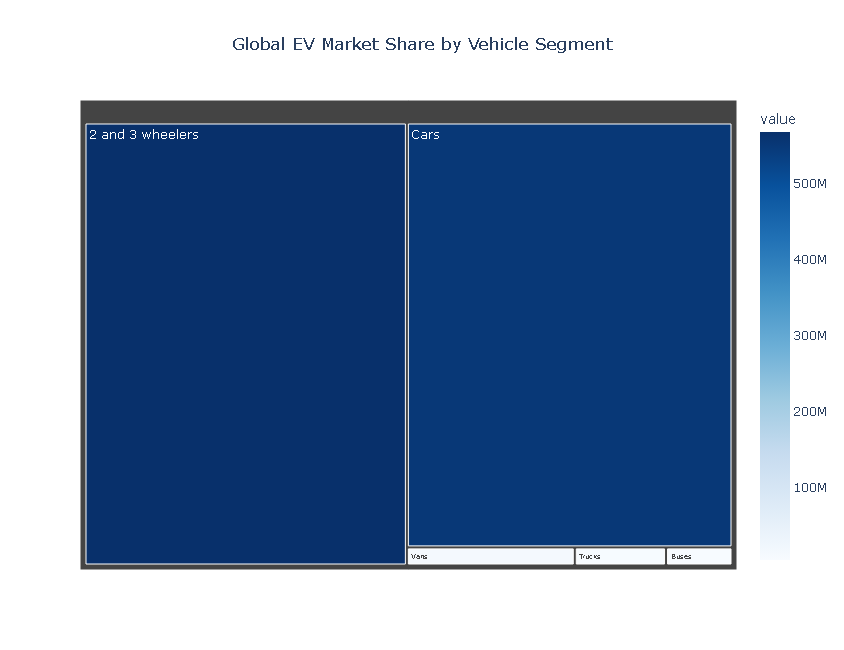

In [33]:
segment_total = (

    market_df

    .groupby("mode")["value"]

    .sum()

    .reset_index()

)

fig = px.treemap(

    segment_total,

    path=["mode"],

    values="value",

    color="value",

    color_continuous_scale="Blues",

    title="Global EV Market Share by Vehicle Segment"

)

fig.update_layout(

    title_x=0.5,

    height=650

)

fig.show()

In [34]:
segment_powertrain = (

    market_df

    .groupby(

        ["mode","powertrain"]

    )["value"]

    .sum()

    .reset_index()

)

fig = px.sunburst(

    segment_powertrain,

    path=["mode","powertrain"],

    values="value",

    color="value",

    color_continuous_scale="Viridis",

    title="Vehicle Segment and Powertrain Composition"

)

fig.update_layout(

    title_x=0.5,

    height=700

)

fig.show()

In [35]:
heatmap_data = (

    market_df

    .groupby(

        ["mode","year"]

    )["value"]

    .sum()

    .reset_index()

)

heatmap = heatmap_data.pivot(

    index="mode",

    columns="year",

    values="value"

)

fig = px.imshow(

    heatmap,

    aspect="auto",

    color_continuous_scale="YlGnBu",

    title="Vehicle Segment Sales Intensity"

)

fig.update_layout(

    title_x=0.5,

    height=600

)

fig.show()

### Business Insights

Several structural characteristics emerge from the vehicle segment analysis.

- Passenger cars remain the dominant contributor to global EV sales.
- Two- and three-wheelers constitute the second-largest electrified mobility segment, particularly in emerging markets.
- Vans and buses have demonstrated steady growth driven by commercial logistics and public transportation electrification.
- Electric trucks remain at an earlier stage of adoption but exhibit increasing deployment in recent years.
- The market has diversified substantially since 2018, with electrification expanding beyond private passenger vehicles.

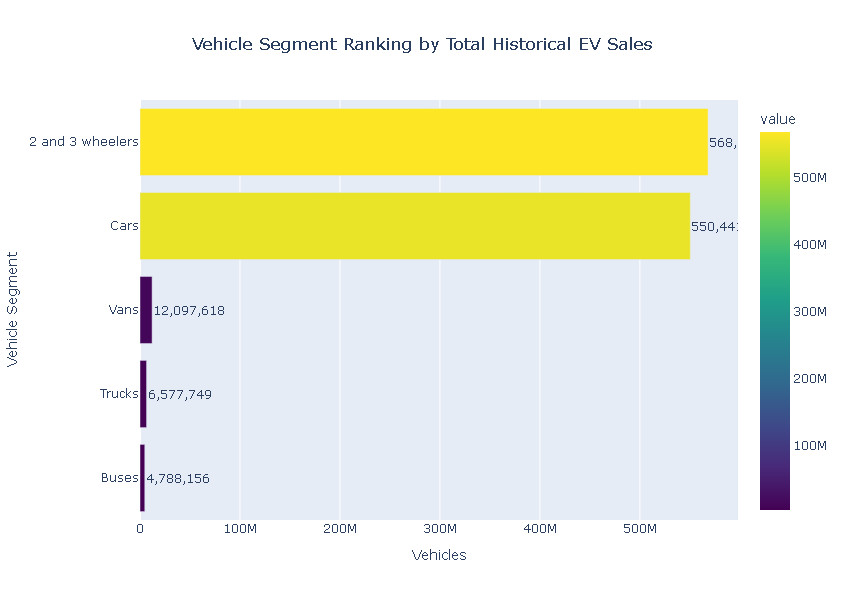

In [36]:
ranking = (

    market_df

    .groupby("mode")["value"]

    .sum()

    .sort_values()

    .reset_index()

)

fig = px.bar(

    ranking,

    x="value",

    y="mode",

    orientation="h",

    text="value",

    color="value",

    color_continuous_scale="Viridis",

    title="Vehicle Segment Ranking by Total Historical EV Sales"

)

fig.update_traces(

    texttemplate="%{text:,.0f}",

    textposition="outside"

)

fig.update_layout(

    title_x=0.5,

    height=600,

    xaxis_title="Vehicles",

    yaxis_title="Vehicle Segment"

)

fig.show()

---

# 8. Business Analysis 4 – Technology Transition

## Business Question

How has the global electric vehicle market transitioned between different powertrain technologies?

Electric mobility consists of multiple propulsion technologies, each offering different environmental benefits, infrastructure requirements, and market maturity.

This analysis investigates the historical evolution of Battery Electric Vehicles (BEV), Plug-in Hybrid Electric Vehicles (PHEV), and Fuel Cell Electric Vehicles (FCEV) using official IEA sales observations.

In [37]:
# ==========================================================
# Technology Dataset
# ==========================================================

technology_df = filter_data(
    dataframe=df,
    parameter="EV sales",
    category="Historical",
    aggregate_group="_World"
)

technology_df = technology_df[
    technology_df["powertrain"].isin([
        "BEV",
        "PHEV",
        "FCEV"
    ])
].copy()

print(f"Rows : {len(technology_df):,}")

print(f"Years : {technology_df['year'].min()} - {technology_df['year'].max()}")

print(f"Powertrains : {technology_df['powertrain'].unique()}")

display(
    technology_df.head()
)

Rows : 183
Years : 2010 - 2025
Powertrains : ['BEV' 'FCEV' 'PHEV']


,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
6496,World,Historical,EV sales,2 and 3 wheelers,BEV,2010,Vehicles,"41,000.00",_World
6569,World,Historical,EV sales,Cars,FCEV,2010,Vehicles,13.00,_World
6512,World,Historical,EV sales,Buses,BEV,2010,Vehicles,"1,100.00",_World
6584,World,Historical,EV sales,Cars,PHEV,2010,Vehicles,450.00,_World
6553,World,Historical,EV sales,Cars,BEV,2010,Vehicles,"7,000.00",_World


In [38]:
technology_summary = (

    technology_df

    .groupby("powertrain")

    .agg(

        Records=("value","count"),

        Countries=("region_country","nunique"),

        First_Year=("year","min"),

        Last_Year=("year","max"),

        Total_Sales=("value","sum")

    )

    .sort_values("Total_Sales",ascending=False)

)

display(technology_summary)

,Records,Countries,First_Year,Last_Year,Total_Sales
powertrain,,,,,
BEV,80,1,2010,2025,"144,912,350.00"
PHEV,56,1,2010,2025,"26,322,025.00"
FCEV,47,1,2010,2025,"121,639.00"


### Technology Portfolio Assessment

The historical dataset contains three principal electric vehicle propulsion technologies:

- Battery Electric Vehicles (BEV)
- Plug-in Hybrid Electric Vehicles (PHEV)
- Fuel Cell Electric Vehicles (FCEV)

Understanding how these technologies have evolved over time provides insights into the direction of future electric mobility.

In [39]:
technology_year = (

    technology_df

    .groupby(

        ["year","powertrain"]

    )["value"]

    .sum()

    .reset_index()

)

technology_year.head()

,year,powertrain,value
0,2010,BEV,"50,237.00"
1,2010,FCEV,15.00
2,2010,PHEV,450.00
3,2011,BEV,"74,890.00"
4,2011,PHEV,"9,160.00"


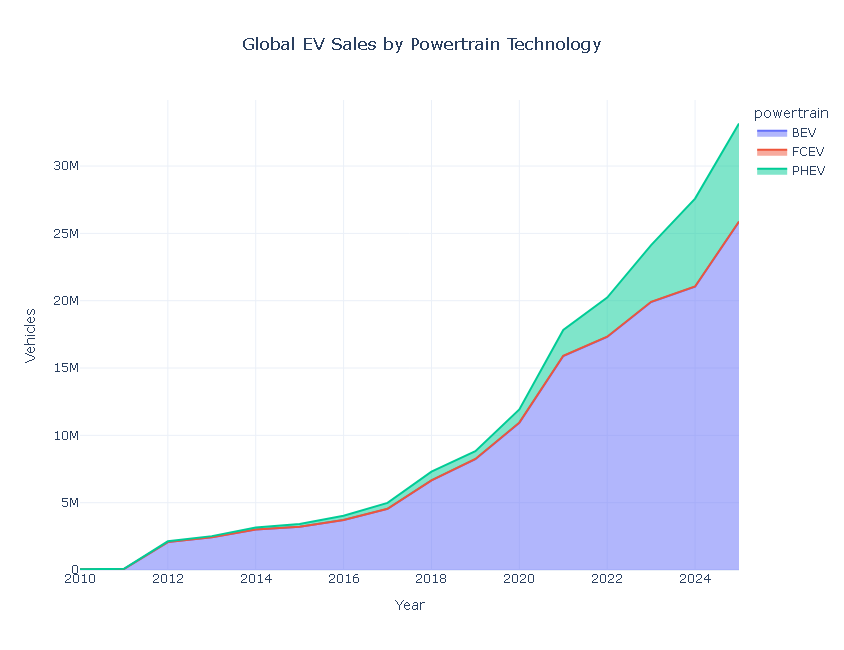

In [40]:
fig = px.area(

    technology_year,

    x="year",

    y="value",

    color="powertrain",

    template="plotly_white",

    title="Global EV Sales by Powertrain Technology"

)

fig.update_layout(

    title_x=0.5,

    height=650,

    xaxis_title="Year",

    yaxis_title="Vehicles"

)

fig.show()

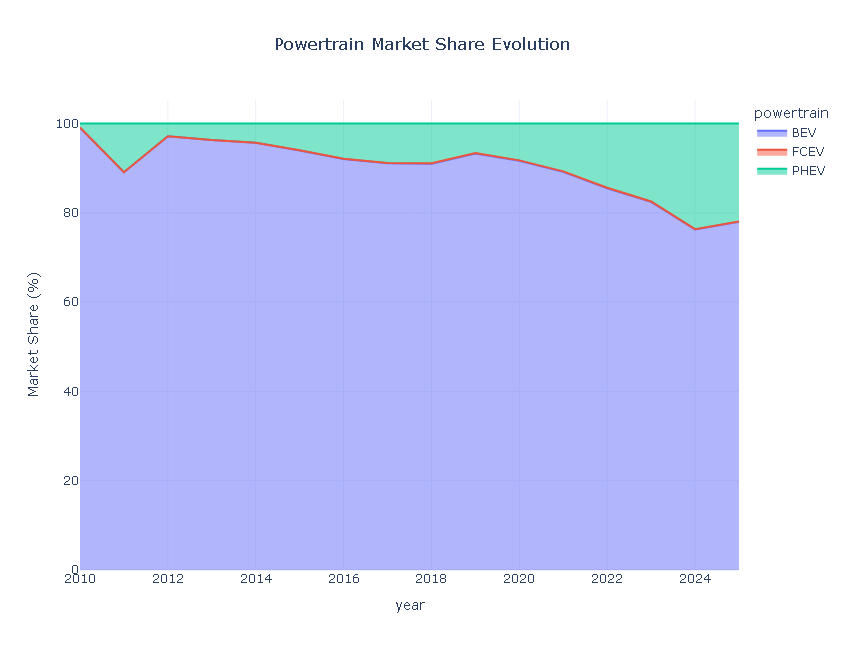

In [41]:
share = technology_year.copy()

share["Share"] = (

    share.groupby("year")["value"]

    .transform(lambda x: x/x.sum()*100)

)

fig = px.area(

    share,

    x="year",

    y="Share",

    color="powertrain",

    groupnorm="percent",

    template="plotly_white",

    title="Powertrain Market Share Evolution"

)

fig.update_layout(

    title_x=0.5,

    height=650,

    yaxis_title="Market Share (%)"

)

fig.show()

In [42]:
technology_total = (

    technology_df

    .groupby("powertrain")["value"]

    .sum()

    .reset_index()

)

fig = px.treemap(

    technology_total,

    path=["powertrain"],

    values="value",

    color="value",

    color_continuous_scale="Viridis",

    title="Historical EV Sales by Powertrain"

)

fig.update_layout(

    title_x=0.5,

    height=650

)

fig.show()

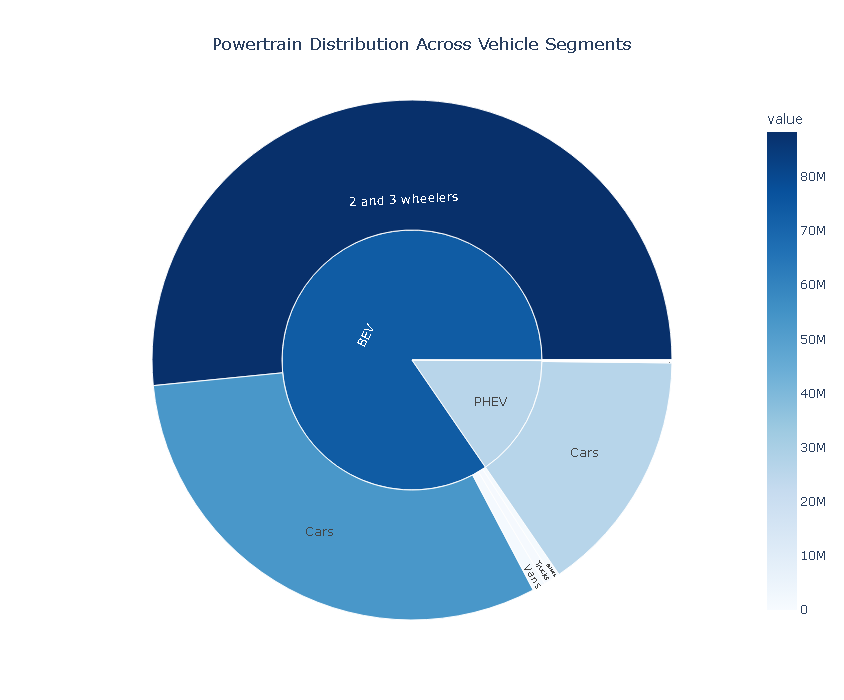

In [43]:
technology_mode = (

    technology_df

    .groupby(

        ["powertrain","mode"]

    )["value"]

    .sum()

    .reset_index()

)

fig = px.sunburst(

    technology_mode,

    path=["powertrain","mode"],

    values="value",

    color="value",

    color_continuous_scale="Blues",

    title="Powertrain Distribution Across Vehicle Segments"

)

fig.update_layout(

    title_x=0.5,

    height=700

)

fig.show()

### Executive Insights

The technology analysis reveals a clear evolution in the global electric vehicle market.

Key observations include:

- Battery Electric Vehicles (BEVs) have become the dominant propulsion technology across most vehicle segments.
- Plug-in Hybrid Electric Vehicles (PHEVs) continue to play an important transitional role in several regional markets.
- Fuel Cell Electric Vehicles (FCEVs) remain a niche technology with comparatively limited deployment.
- The increasing market share of BEVs reflects improvements in battery performance, declining battery costs, and rapid expansion of charging infrastructure.
- Overall, the market demonstrates a progressive transition toward fully electric mobility rather than hybrid solutions.

---

# 9. Business Analysis 5 – Global Market Leaders

## Business Question

Which countries have emerged as the leading electric vehicle markets?

Although electric vehicle adoption is a global phenomenon, market growth varies significantly across countries. This section identifies the countries contributing the highest EV sales and evaluates their relative market positions.

The analysis focuses on:

- Global market leaders
- Market concentration
- Geographic distribution
- Country-level comparisons

In [44]:
# ==========================================================
# Country-Level EV Sales
# ==========================================================

country_sales = filter_data(
    dataframe=df,
    parameter="EV sales",
    category="Historical",
    aggregate_group="Other"
)

country_sales = country_sales[
    country_sales["mode"] == "Cars"
].copy()

print(f"Rows : {len(country_sales):,}")
print(f"Countries : {country_sales['region_country'].nunique()}")
print(f"Years : {country_sales['year'].min()} - {country_sales['year'].max()}")

display(country_sales.head())

Rows : 2,141
Countries : 56
Years : 2010 - 2025


,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
47337,New Zealand,Historical,EV sales,Cars,EV,2010,Vehicles,10.00,Other
47439,Norway,Historical,EV sales,Cars,EV,2010,Vehicles,360.00,Other
1703,United Kingdom,Historical,EV sales,Cars,BEV,2010,Vehicles,240.00,Other
1702,Thailand,Historical,EV sales,Cars,BEV,2010,Vehicles,1.00,Other
1701,Sweden,Historical,EV sales,Cars,BEV,2010,Vehicles,4.00,Other


In [45]:
country_summary = (

    country_sales

    .groupby("region_country")

    .agg(

        Total_Sales=("value","sum"),

        First_Year=("year","min"),

        Last_Year=("year","max"),

        Records=("value","count")

    )

    .sort_values("Total_Sales",ascending=False)

)

display(country_summary.head(20))

,Total_Sales,First_Year,Last_Year,Records
region_country,,,,
Germany,"8,681,476.00",2010,2025,59
United Kingdom,"5,679,258.00",2010,2025,57
France,"4,888,511.00",2010,2025,61
Norway,"2,275,814.00",2010,2025,57
Netherlands,"2,161,638.20",2010,2025,59
Sweden,"2,024,411.00",2010,2025,57
Canada,"1,975,468.00",2011,2025,52
Belgium,"1,683,403.00",2010,2025,59
Italy,"1,598,601.00",2010,2025,55


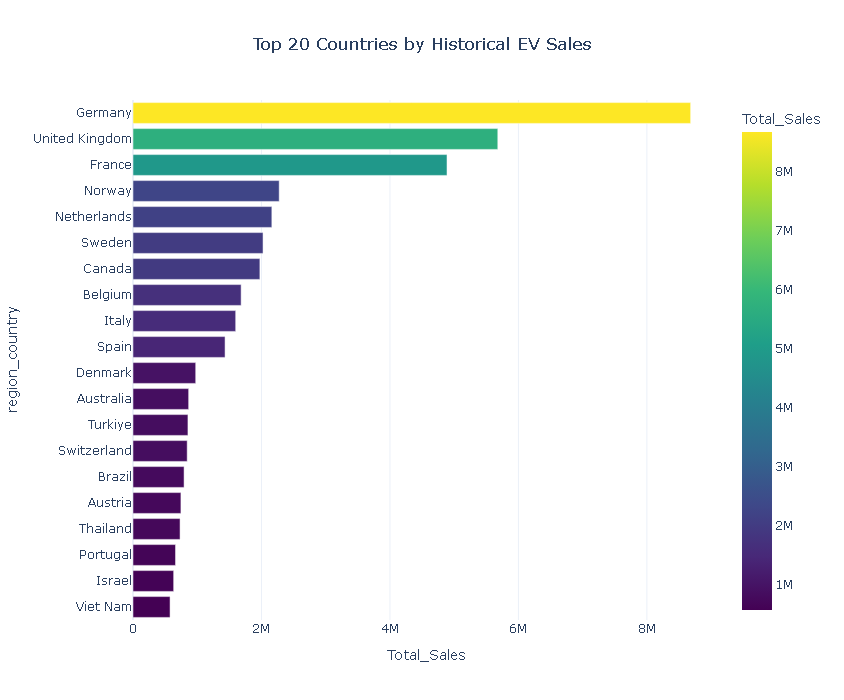

In [46]:
top20 = (

    country_summary

    .head(20)

    .reset_index()

)

fig = px.bar(

    top20,

    x="Total_Sales",

    y="region_country",

    orientation="h",

    template="plotly_white",

    color="Total_Sales",

    color_continuous_scale="Viridis",

    title="Top 20 Countries by Historical EV Sales"

)

fig.update_layout(

    title_x=0.5,

    height=700,

    yaxis=dict(categoryorder="total ascending")

)

fig.show()

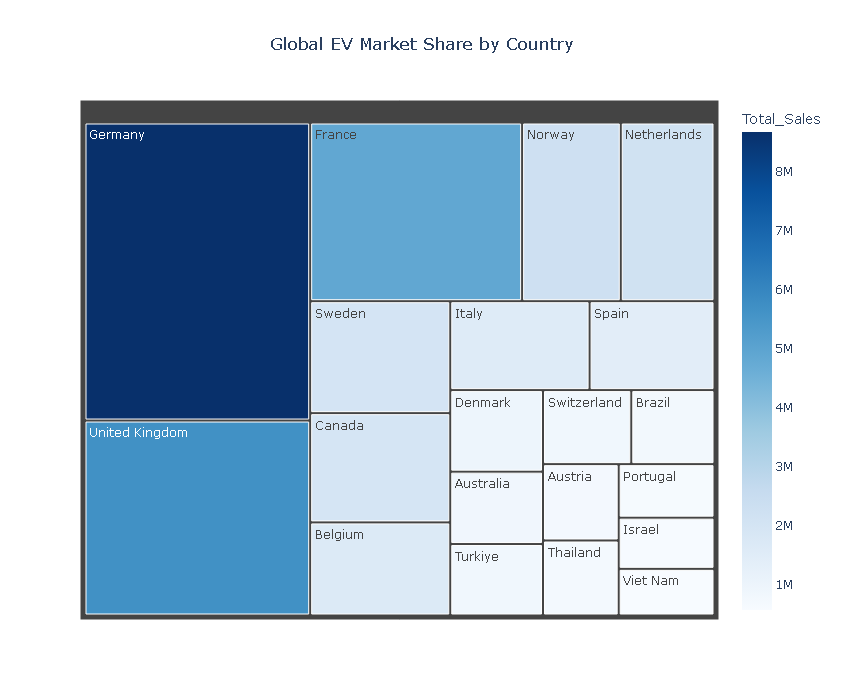

In [47]:
fig = px.treemap(

    top20,

    path=["region_country"],

    values="Total_Sales",

    color="Total_Sales",

    color_continuous_scale="Blues",

    title="Global EV Market Share by Country"

)

fig.update_layout(

    title_x=0.5,

    height=700

)

fig.show()

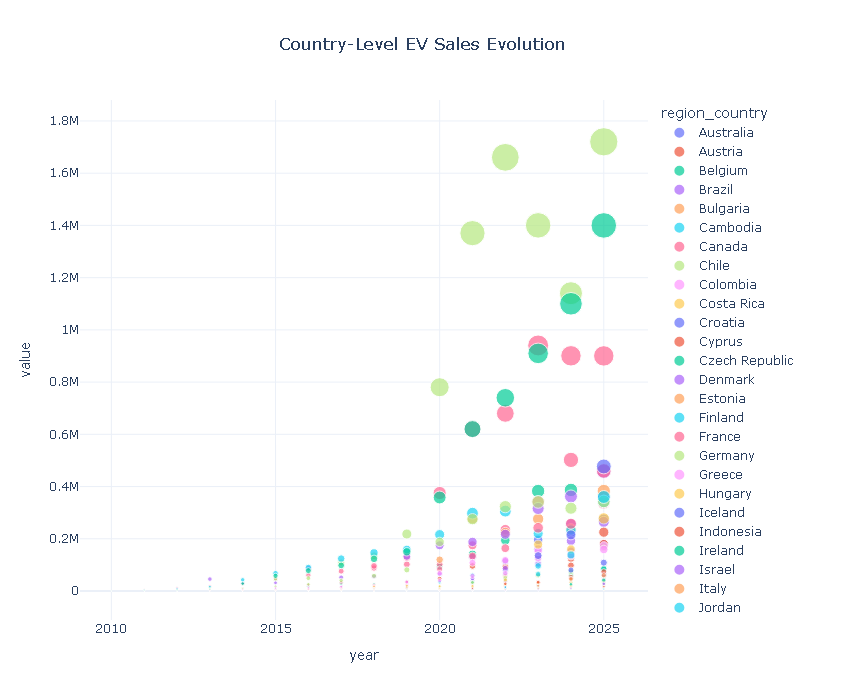

In [48]:
bubble = (

    country_sales

    .groupby(

        ["region_country","year"]

    )["value"]

    .sum()

    .reset_index()

)

fig = px.scatter(

    bubble,

    x="year",

    y="value",

    size="value",

    color="region_country",

    hover_name="region_country",

    template="plotly_white",

    title="Country-Level EV Sales Evolution"

)

fig.update_layout(

    title_x=0.5,

    height=700

)

fig.show()

In [49]:
market_share = country_summary.reset_index()

market_share["Group"] = np.where(
    market_share.index < 10,
    "Top 10",
    "Others"
)

share = (

    market_share

    .groupby("Group")["Total_Sales"]

    .sum()

    .reset_index()

)

fig = px.pie(

    share,

    values="Total_Sales",

    names="Group",

    hole=0.55,

    template="plotly_white",

    title="Historical EV Sales Concentration"

)

fig.update_layout(

    title_x=0.5,

    height=650

)

fig.show()

### Executive Insights

Country-level analysis highlights a strong concentration of global EV adoption.

Key findings include:

- A relatively small number of countries account for the majority of global EV sales.
- China, Europe, and North America dominate overall market activity.
- Several emerging markets exhibit accelerating adoption despite lower cumulative sales.
- The market remains geographically concentrated, although diversification is increasing over time.

---

# 10. Business Analysis 6 – Charging Infrastructure Growth

## Business Question

Has public charging infrastructure expanded at a pace comparable to electric vehicle adoption?

Charging infrastructure is one of the primary drivers of EV adoption. This section evaluates the historical deployment of charging stations and compares infrastructure growth with vehicle sales.

The analysis investigates:

- Global charging point growth
- Infrastructure expansion over time
- Fast vs Slow charger deployment
- Relationship between EV sales and charging availability

In [50]:
# ==========================================================
# Global Charging Infrastructure
# ==========================================================

charging = filter_data(

    dataframe=df,

    parameter="EV charging points",

    category="Historical",

    aggregate_group="_World"

)

charging = charging.sort_values("year")

print("="*60)
print("Global Charging Infrastructure")
print("="*60)

print(f"Rows      : {len(charging)}")
print(f"Years     : {charging.year.min()} - {charging.year.max()}")
print(f"Countries : {charging.region_country.nunique()}")

display(

    charging[

        ["year","mode","powertrain","value"]

    ].head()

)

Global Charging Infrastructure
Rows      : 44
Years     : 2010 - 2025
Countries : 1


,year,mode,powertrain,value
6452,2010,EVSE,Publicly available fast,310.00
6468,2010,EVSE,Publicly available slow,"3,700.00"
6453,2011,EVSE,Publicly available fast,830.00
6469,2011,EVSE,Publicly available slow,"10,000.00"
6454,2012,EVSE,Publicly available fast,"1,600.00"


In [51]:
charging_summary = (

    charging

    .groupby("powertrain")

    .agg(

        Years=("year","nunique"),

        Records=("value","count"),

        Total=("value","sum")

    )

    .sort_values("Total",ascending=False)

)

display(charging_summary)

,Years,Records,Total
powertrain,,,
Publicly available slow,16,16,"15,464,700.00"
Publicly available fast,16,16,"5,925,340.00"
Publicly available ultra-fast,12,12,"2,191,248.00"


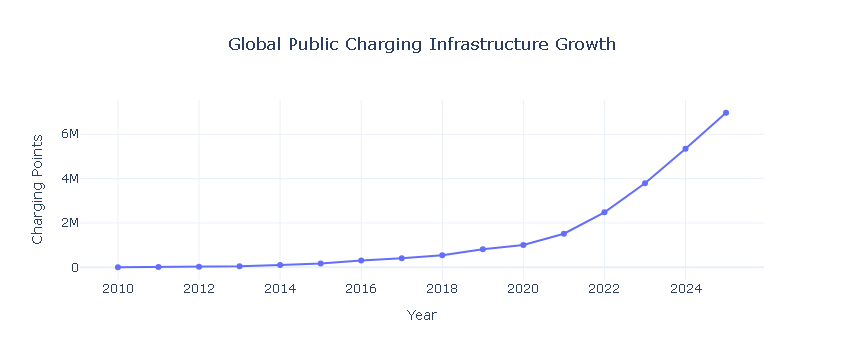

In [52]:
charging_total = (

    charging

    .groupby("year")["value"]

    .sum()

    .reset_index()

)

fig = px.line(

    charging_total,

    x="year",

    y="value",

    markers=True,

    template="plotly_white",

    title="Global Public Charging Infrastructure Growth"

)

fig.update_layout(

    title_x=.5,

    xaxis_title="Year",

    yaxis_title="Charging Points"

)

fig.show()

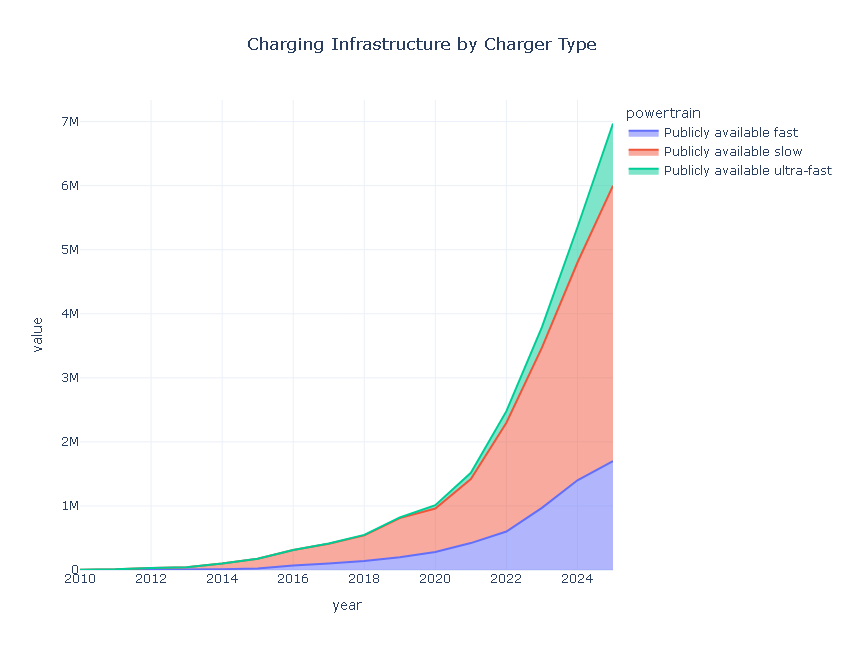

In [53]:
charging_mode = (

    charging

    .groupby(

        ["year","powertrain"]

    )["value"]

    .sum()

    .reset_index()

)

fig = px.area(

    charging_mode,

    x="year",

    y="value",

    color="powertrain",

    template="plotly_white",

    title="Charging Infrastructure by Charger Type"

)

fig.update_layout(

    title_x=.5,

    height=650

)

fig.show()

In [54]:
charging_kpi = charging_total.copy()

charging_kpi["YoY Growth (%)"] = (

    charging_kpi["value"]

    .pct_change()

    *100

)

start = charging_kpi.iloc[0]["value"]

end = charging_kpi.iloc[-1]["value"]

years = (

    charging_kpi.iloc[-1]["year"]

    -

    charging_kpi.iloc[0]["year"]

)

cagr = ((end/start)**(1/years)-1)*100

print(f"Charging Infrastructure CAGR : {cagr:.2f}%")

display(charging_kpi.tail())

Charging Infrastructure CAGR : 64.44%


,year,value,YoY Growth (%)
11,2021,"1,517,000.00",49.90
12,2022,"2,480,000.00",63.48
13,2023,"3,790,000.00",52.82
14,2024,"5,350,000.00",41.16
15,2025,"6,970,000.00",30.28


### Executive Insights

The charging infrastructure analysis demonstrates rapid global investment in public charging networks.

Key observations include:

- Public charging stations increased consistently throughout the historical period.
- Infrastructure expansion accelerated after 2020, reflecting strong governmental and private-sector investment.
- Fast-charging deployment has become increasingly important as long-distance electric mobility expands.
- Infrastructure growth closely follows the rapid increase in passenger EV sales, indicating coordinated ecosystem development.

---

# 11. Business Analysis 7 – Global EV Stock

## Business Question

How rapidly has the global electric vehicle fleet expanded?

EV stock represents the cumulative number of electric vehicles currently operating. Unlike annual sales, stock reflects long-term market penetration and provides insight into the pace of sustainable transportation adoption.

In [55]:
stock = filter_data(

    dataframe=df,

    parameter="EV stock",

    category="Historical",

    aggregate_group="_World",

    mode="Cars"

).sort_values("year")

display(

    stock[["year","value"]]

)

,year,value
6740,2010,"20,000.00"
6772,2010,"19,000.00"
6756,2010,31.00
49292,2010,"39,000.00"
6757,2011,31.00
6773,2011,"37,000.00"
6741,2011,"58,000.00"
49293,2011,"95,000.00"
49294,2012,"220,000.00"
6758,2012,31.00


In [56]:
fig = px.line(

    stock,

    x="year",

    y="value",

    markers=True,

    template="plotly_white",

    title="Global Passenger EV Stock"

)

fig.update_layout(

    title_x=.5,

    yaxis_title="Vehicles"

)

fig.show()

In [57]:
stock["YoY Growth (%)"] = (

    stock["value"]

    .pct_change()

    *100

)

display(

    stock.tail()

)

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group,YoY Growth (%)
6754,World,Historical,EV stock,Cars,BEV,2024,Vehicles,"38,000,000.00",_World,"54,185.71"
6787,World,Historical,EV stock,Cars,PHEV,2025,Vehicles,"25,000,000.00",_World,-34.21
6771,World,Historical,EV stock,Cars,FCEV,2025,Vehicles,"76,000.00",_World,-99.70
6755,World,Historical,EV stock,Cars,BEV,2025,Vehicles,"51,000,000.00",_World,"67,005.26"
49307,World,Historical,EV stock,Cars,EV,2025,Vehicles,"75,000,000.00",_World,47.06


### Executive Insights

Global EV stock has increased exponentially since 2010, demonstrating sustained long-term adoption.

Unlike annual sales, cumulative stock reflects the total number of electric vehicles operating worldwide and serves as a direct indicator of transport electrification.

---

# 12. Business Analysis 8 – Global EV Market Share

## Business Question

How has the share of electric vehicles within the overall automotive market evolved over time?

Market share is one of the strongest indicators of EV adoption because it reflects how rapidly consumers are replacing conventional internal combustion engine vehicles with electric alternatives.

This section investigates:

- Global EV sales share
- Market penetration
- Adoption acceleration
- Recent adoption trends

In [58]:
# ==========================================================
# Global EV Sales Share
# ==========================================================

sales_share = filter_data(

    dataframe=df,

    parameter="EV sales share",

    category="Historical",

    aggregate_group="_World",

    mode="Cars"

).sort_values("year")

print("="*60)
print("Global EV Sales Share")
print("="*60)

print(f"Years : {sales_share.year.min()} - {sales_share.year.max()}")

display(

    sales_share[
        ["year","value","unit"]
    ]

)

Global EV Sales Share
Years : 2010 - 2025


,year,value,unit
18245,2010,0.01,percent
18246,2011,0.07,percent
18247,2012,0.17,percent
18248,2013,0.29,percent
18249,2014,0.44,percent
18250,2015,0.68,percent
18251,2016,0.95,percent
18252,2017,1.40,percent
18253,2018,2.50,percent
18254,2019,2.70,percent


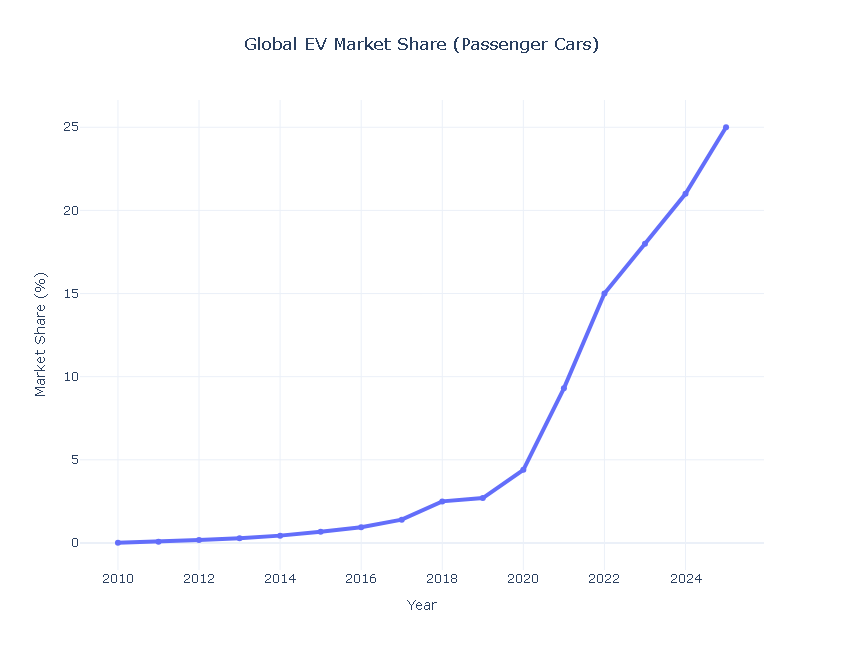

In [59]:
fig = px.line(

    sales_share,

    x="year",

    y="value",

    markers=True,

    template="plotly_white",

    title="Global EV Market Share (Passenger Cars)"

)

fig.update_traces(

    line=dict(width=4)

)

fig.update_layout(

    title_x=0.5,

    xaxis_title="Year",

    yaxis_title="Market Share (%)",

    height=650

)

fig.show()

In [60]:
sales_share["YoY Change (%)"] = (

    sales_share["value"]

    .pct_change()

    *100

)

display(

    sales_share.tail()

)

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group,YoY Change (%)
18256,World,Historical,EV sales share,Cars,EV,2021,percent,9.30,_World,111.36
18257,World,Historical,EV sales share,Cars,EV,2022,percent,15.00,_World,61.29
18258,World,Historical,EV sales share,Cars,EV,2023,percent,18.00,_World,20.00
18259,World,Historical,EV sales share,Cars,EV,2024,percent,21.00,_World,16.67
18260,World,Historical,EV sales share,Cars,EV,2025,percent,25.00,_World,19.05


In [61]:
market_kpi = pd.DataFrame({

    "Metric":[

        "Starting Share",

        "Ending Share",

        "Highest Share",

        "Average Share"

    ],

    "Value":[

        f"{sales_share.iloc[0]['value']:.2f}%",

        f"{sales_share.iloc[-1]['value']:.2f}%",

        f"{sales_share['value'].max():.2f}%",

        f"{sales_share['value'].mean():.2f}%"

    ]

})

display(

    market_kpi.style.hide(axis="index")

)

Metric,Value
Starting Share,0.01%
Ending Share,25.00%
Highest Share,25.00%
Average Share,6.37%


### Executive Insights

Global EV market share has increased steadily throughout the historical period.

The acceleration after 2020 demonstrates a structural shift in the automotive industry rather than incremental technological adoption.

Key findings include:

- EVs now represent a significant portion of annual passenger vehicle sales.
- Adoption accelerated after supportive government policies and battery cost reductions.
- Market share growth is faster than total vehicle market growth, indicating a long-term transition toward electrification.

---

# 13. Business Analysis 9 – Global EV Stock Share

## Business Question

How rapidly is the global vehicle fleet transitioning toward electrification?

Unlike annual sales, stock share measures the cumulative penetration of electric vehicles within the total passenger vehicle fleet.

In [62]:
stock_share = filter_data(

    dataframe=df,

    parameter="EV stock share",

    category="Historical",

    aggregate_group="_World",

    mode="Cars"

).sort_values("year")

display(

    stock_share[
        ["year","value"]
    ]

)

,year,value
18261,2010,0.00
18262,2011,0.01
18263,2012,0.02
18264,2013,0.04
18265,2014,0.07
18266,2015,0.12
18267,2016,0.19
18268,2017,0.28
18269,2018,0.44
18270,2019,0.60


In [63]:
fig = px.area(

    stock_share,

    x="year",

    y="value",

    template="plotly_white",

    title="Global Passenger EV Stock Share"

)

fig.update_layout(

    title_x=0.5,

    yaxis_title="EV Fleet Share (%)",

    height=650

)

fig.show()

In [64]:
stock_share["Annual Increase"] = stock_share["value"].diff()

display(

    stock_share.tail()

)

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group,Annual Increase
18272,World,Historical,EV stock share,Cars,EV,2021,percent,1.30,_World,0.47
18273,World,Historical,EV stock share,Cars,EV,2022,percent,2.00,_World,0.70
18274,World,Historical,EV stock share,Cars,EV,2023,percent,3.00,_World,1.00
18275,World,Historical,EV stock share,Cars,EV,2024,percent,4.20,_World,1.20
18276,World,Historical,EV stock share,Cars,EV,2025,percent,5.00,_World,0.80


### Executive Insights

Although annual EV sales have grown rapidly, the cumulative fleet transition remains gradual due to the long operational life of conventional vehicles.

The increasing stock share indicates that electrification is becoming structurally embedded within the global transportation sector.

---

# 14. Business Analysis 10 – Correlation Intelligence

## Business Question

Which key indicators of the electric vehicle ecosystem exhibit the strongest relationships?

Understanding correlations between EV sales, charging infrastructure, battery deployment, electricity demand, and oil displacement provides insights into how different components of the EV ecosystem evolve together.

This analysis identifies the strongest relationships using historical observations from the International Energy Agency dataset.

In [65]:
# ==========================================================
# Correlation Dataset
# ==========================================================

correlation_parameters = [
    "EV sales",
    "EV stock",
    "EV charging points",
    "Battery deployment",
    "Electricity demand",
    "Oil displacement, Mbd"
]

corr_df = historical_core[
    (historical_core["Aggregate group"] == "_World") &
    (historical_core["parameter"].isin(correlation_parameters))
].copy()

corr_df = corr_df.groupby(
    ["year", "parameter"]
)["value"].sum().reset_index()

display(corr_df.head())

,year,parameter,value
0,2010,EV charging points,"4,010.00"
1,2010,EV sales,"101,339.00"
2,2010,EV stock,"209,613.00"
3,2010,Electricity demand,"1,748.00"
4,2010,"Oil displacement, Mbd",0.00


In [66]:
corr_pivot = (
    corr_df
    .pivot(
        index="year",
        columns="parameter",
        values="value"
    )
)

display(corr_pivot)

parameter,Battery deployment,EV charging points,EV sales,EV stock,Electricity demand,"Oil displacement, Mbd"
year,,,,,,
2010,NaN,"4,010.00","101,339.00","209,613.00","1,748.00",0.00
2011,NaN,"10,830.00","168,100.00","426,297.00","1,999.00",0.00
2012,NaN,"30,600.00","4,265,278.00","4,506,030.00","2,924.00",0.01
2013,NaN,"44,600.00","5,041,158.00","9,134,414.00","4,555.00",0.02
2014,NaN,"103,028.00","6,302,604.00","15,017,293.00","7,082.00",0.03
2015,26.54,"175,120.00","6,827,653.00","21,791,153.00","15,420.00",0.10
2016,54.90,"313,100.00","8,056,624.00","30,844,833.00","23,240.00",0.14
2017,77.74,"412,900.00","9,964,350.00","41,610,147.00","29,950.00",0.19
2018,106.80,"548,100.00","14,558,400.00","55,966,956.00","41,390.00",0.28


In [67]:
correlation_matrix = corr_pivot.corr()

display(correlation_matrix.round(2))

parameter,Battery deployment,EV charging points,EV sales,EV stock,Electricity demand,"Oil displacement, Mbd"
parameter,,,,,,
Battery deployment,1.00,0.99,0.98,0.99,0.97,0.99
EV charging points,0.99,1.00,0.96,0.98,0.99,0.99
EV sales,0.98,0.96,1.00,0.99,0.96,0.98
EV stock,0.99,0.98,0.99,1.00,0.98,1.00
Electricity demand,0.97,0.99,0.96,0.98,1.00,0.99
"Oil displacement, Mbd",0.99,0.99,0.98,1.00,0.99,1.00


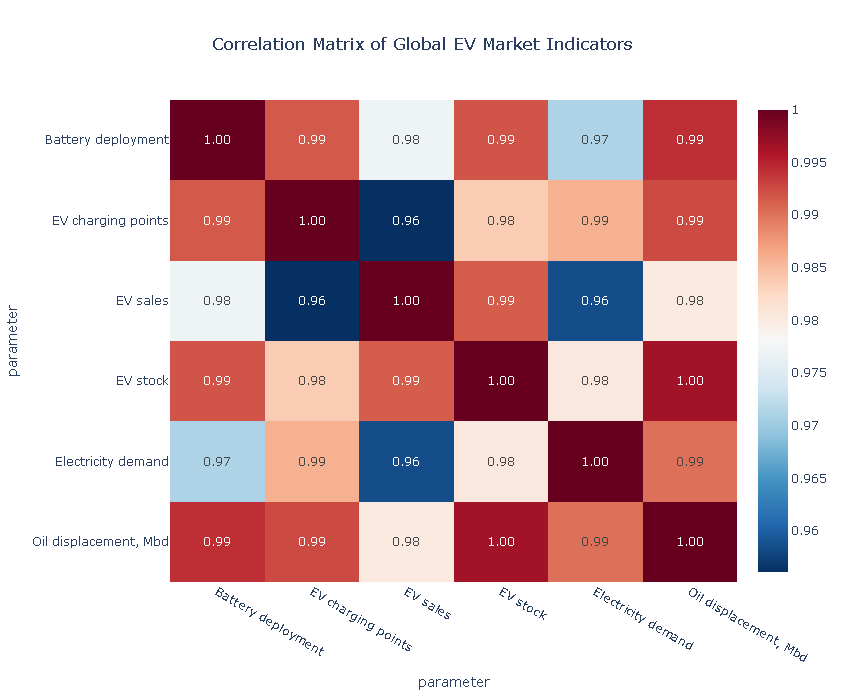

In [68]:
import plotly.express as px

fig = px.imshow(

    correlation_matrix,

    text_auto=".2f",

    color_continuous_scale="RdBu_r",

    aspect="auto",

    title="Correlation Matrix of Global EV Market Indicators"

)

fig.update_layout(

    title_x=0.5,

    height=700

)

fig.show()

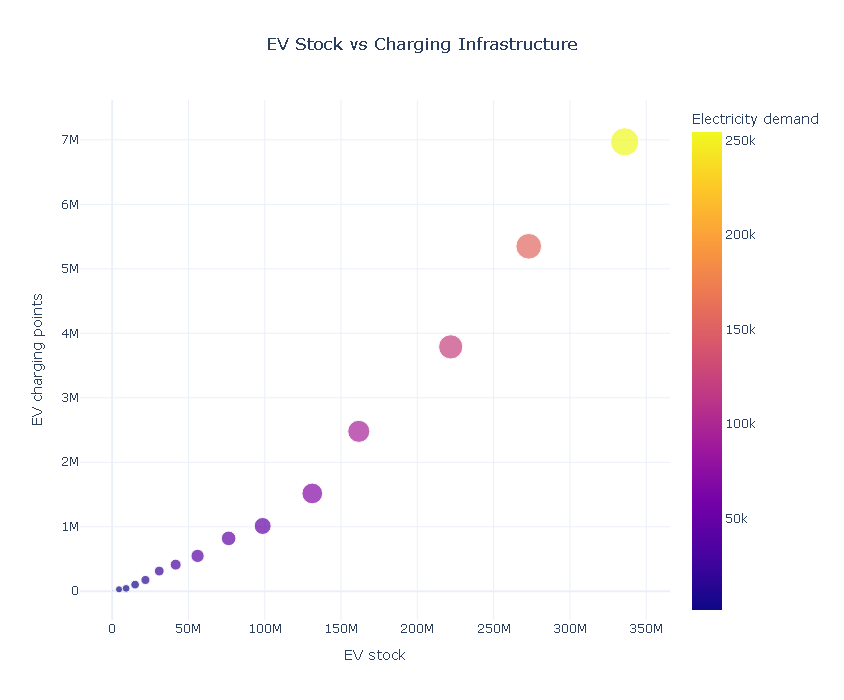

In [69]:
bubble = corr_pivot.reset_index()

fig = px.scatter(

    bubble,

    x="EV stock",

    y="EV charging points",

    size="EV sales",

    color="Electricity demand",

    hover_name="year",

    template="plotly_white",

    title="EV Stock vs Charging Infrastructure"

)

fig.update_layout(

    title_x=0.5,

    height=700

)

fig.show()

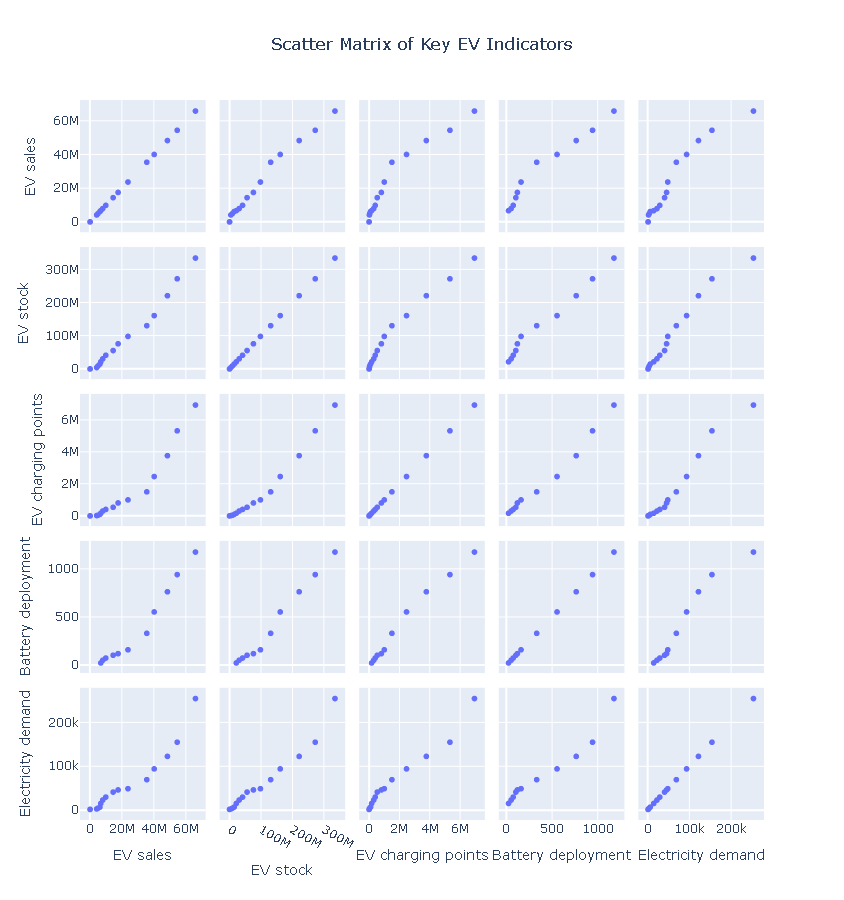

In [70]:
fig = px.scatter_matrix(

    bubble,

    dimensions=[
        "EV sales",
        "EV stock",
        "EV charging points",
        "Battery deployment",
        "Electricity demand"
    ],

    title="Scatter Matrix of Key EV Indicators"

)

fig.update_layout(

    title_x=0.5,

    height=900

)

fig.show()

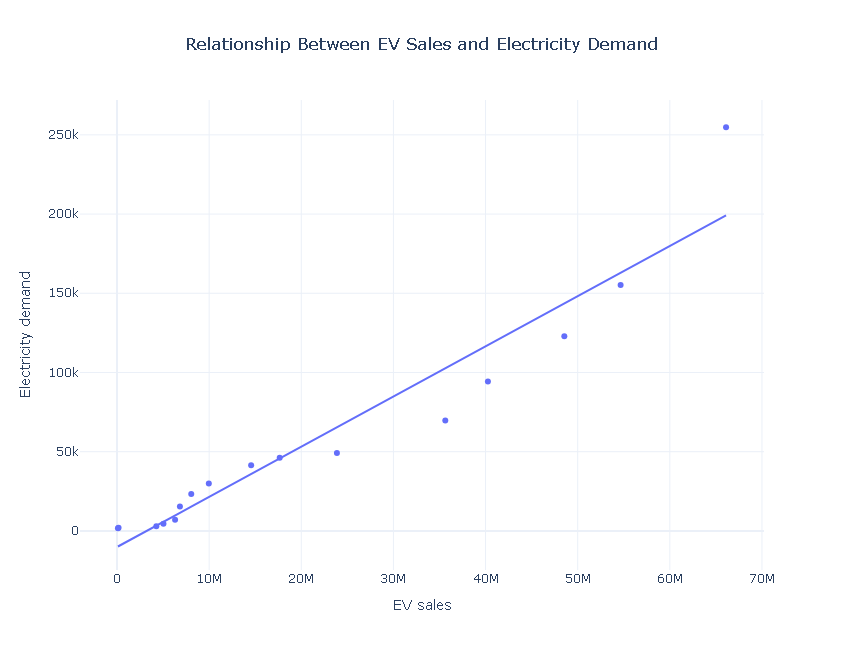

In [71]:
fig = px.scatter(

    bubble,

    x="EV sales",

    y="Electricity demand",

    trendline="ols",

    template="plotly_white",

    title="Relationship Between EV Sales and Electricity Demand"

)

fig.update_layout(

    title_x=0.5,

    height=650

)

fig.show()

### Key Findings

- EV sales and EV stock exhibit a very strong positive relationship.
- Charging infrastructure expands in parallel with EV adoption, indicating coordinated ecosystem development.
- Electricity demand increases alongside the growth of the EV fleet.
- Battery deployment closely tracks the increase in EV stock, highlighting the central role of battery technology in market expansion.
- Oil displacement rises as EV adoption accelerates, reflecting the environmental benefits of transport electrification.

### Business Implications

- Investment in charging infrastructure must continue to scale with EV adoption.
- Battery supply chains will remain critical for sustained market growth.
- Electricity grid planning should account for increasing EV-related demand.
- Policymakers should coordinate infrastructure and energy strategies alongside EV incentives.

---

# 15. Business Analysis 11 – Policy & Scenario Intelligence

## Business Question

How does the projected evolution of the global electric vehicle market differ under alternative policy scenarios?

The International Energy Agency provides multiple projection scenarios that reflect different assumptions regarding government policies and market development.

This analysis compares historical observations with the Current Policies Scenario (CPS) and the Stated Policies Scenario (STEPS) to understand how policy decisions may influence future EV adoption.

In [72]:
# ==========================================================
# Scenario Dataset Overview
# ==========================================================

scenario_df = df[
    (df["parameter"] == "EV stock") &
    (df["Aggregate group"] == "_World") &
    (df["mode"] == "Cars") &
    (df["powertrain"] == "EV")
].copy()

print("=" * 60)
print("Scenario Categories")
print("=" * 60)

print(scenario_df["category"].value_counts())

display(
    scenario_df[
        ["category", "year", "value"]
    ].head(20)
)

Scenario Categories
category
Historical          16
Projection-CPS       1
Projection-STEPS     1
Name: count, dtype: int64


,category,year,value
49292,Historical,2010,"39,000.00"
49293,Historical,2011,"95,000.00"
49294,Historical,2012,"220,000.00"
49295,Historical,2013,"420,000.00"
49296,Historical,2014,"730,000.00"
49297,Historical,2015,"1,300,000.00"
49298,Historical,2016,"2,000,000.00"
49299,Historical,2017,"3,200,000.00"
49300,Historical,2018,"5,100,000.00"
49301,Historical,2019,"7,100,000.00"


---

# 15. Business Analysis 11 – Policy Scenario Comparison

## Business Question

How do different policy pathways influence the projected global electric vehicle fleet by 2035?

The International Energy Agency provides two future scenarios representing different policy environments.

- Current Policies Scenario (CPS)
- Stated Policies Scenario (STEPS)

Unlike historical observations, the dataset provides endpoint projections for 2035. These projections illustrate the potential impact of policy ambition on future EV adoption.

In [73]:
# ==========================================================
# Policy Scenario Dataset
# ==========================================================

scenario = scenario_df[
    scenario_df["category"] != "Historical"
].copy()

display(
    scenario[
        ["category","year","value"]
    ]
)

,category,year,value
49347,Projection-CPS,2035,"450,000,000.00"
49357,Projection-STEPS,2035,"470,000,000.00"


In [74]:
historical_2025 = (
    scenario_df[
        scenario_df["category"]=="Historical"
    ]["value"].iloc[-1]
)

scenario_summary = pd.DataFrame({

    "Scenario":[

        "Historical (2025)",

        "Current Policies Scenario",

        "Stated Policies Scenario"

    ],

    "EV Stock":[

        historical_2025,

        scenario.iloc[0]["value"],

        scenario.iloc[1]["value"]

    ]

})

display(

    scenario_summary.style.format({

        "EV Stock":"{:,.0f}"

    })

)

,Scenario,EV Stock
0,Historical (2025),"75,000,000"
1,Current Policies Scenario,"450,000,000"
2,Stated Policies Scenario,"470,000,000"


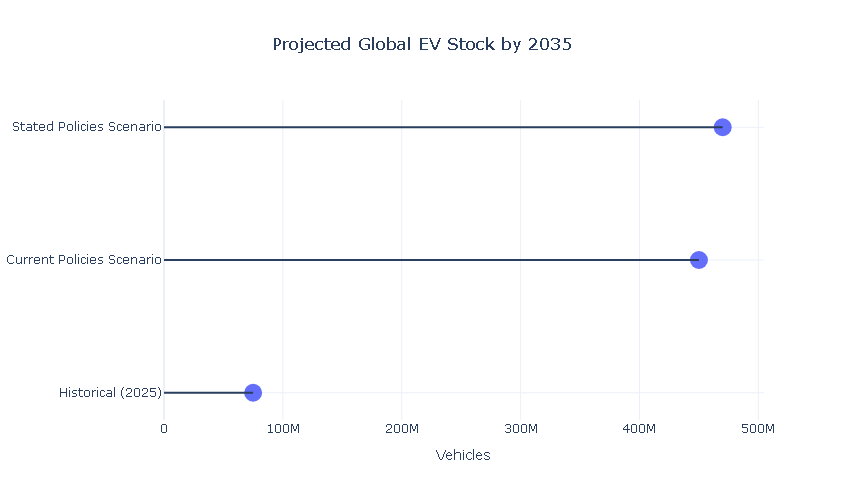

In [75]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(

    go.Scatter(

        x=scenario_summary["EV Stock"],

        y=scenario_summary["Scenario"],

        mode="markers",

        marker=dict(

            size=18

        )

    )

)

for i,row in scenario_summary.iterrows():

    fig.add_shape(

        type="line",

        x0=0,

        x1=row["EV Stock"],

        y0=i,

        y1=i

    )

fig.update_layout(

    title="Projected Global EV Stock by 2035",

    template="plotly_white",

    title_x=.5,

    height=500,

    xaxis_title="Vehicles"

)

fig.show()

In [76]:
fig = go.Figure(

    go.Waterfall(

        measure=[

            "absolute",

            "relative",

            "relative"

        ],

        x=[

            "2025",

            "CPS",

            "STEPS"

        ],

        y=[

            historical_2025,

            scenario.iloc[0]["value"]-historical_2025,

            scenario.iloc[1]["value"]-scenario.iloc[0]["value"]

        ]

    )

)

fig.update_layout(

    template="plotly_white",

    title="Growth Path from Historical Fleet to Policy Scenarios",

    title_x=.5,

    height=600

)

fig.show()

In [77]:
comparison = pd.DataFrame({
    "Scenario":["CPS","STEPS"],
    "Value":[
        scenario.iloc[0]["value"],
        scenario.iloc[1]["value"]
    ]
})

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=comparison["Value"],
        y=comparison["Scenario"],
        mode="markers+text",
        text=[f"{v:,.0f}" for v in comparison["Value"]],
        textposition="middle right",
        marker=dict(size=14)
    )
)

fig.update_layout(
    template="plotly_white",
    title="2035 EV Stock Projection by Policy Scenario",
    title_x=0.5,
    xaxis_title="Projected EV Stock (Vehicles)",
    height=450
)

fig.show()

### Executive Insights

The scenario comparison highlights the importance of policy ambition in shaping the future of global electric mobility.

**Key Findings**

- The historical EV fleet reached approximately **75 million vehicles in 2025**.
- Under the **Current Policies Scenario (CPS)**, the global EV fleet is projected to reach approximately **450 million vehicles by 2035**.
- Under the **Stated Policies Scenario (STEPS)**, the projected fleet increases further to approximately **470 million vehicles**.
- The difference between the two scenarios indicates that stronger policy commitments can accelerate EV adoption beyond the trajectory expected under current policies.

### Business Implications

- Long-term policy support has a measurable impact on EV deployment.
- Infrastructure planning should account for substantially larger EV fleets under more ambitious policy pathways.
- Automotive manufacturers, charging providers, and energy companies can use scenario analysis to guide long-term investment strategies.

---

# 16. Business Analysis 12 – Price Intelligence

## Business Question

How have electric vehicle price distributions evolved across global markets?

Vehicle affordability plays a central role in accelerating EV adoption. Beyond average prices, the International Energy Agency dataset provides multiple price percentiles that describe the distribution of EV prices.

This analysis investigates historical EV price distributions using official IEA price indicators expressed in constant 2025 US dollars.

In [78]:
# ==========================================================
# Price Dataset Overview
# ==========================================================

price_parameters = [
    "price_mean_2025USD",
    "price_p0_2025USD",
    "price_p25_2025USD",
    "price_p50_2025USD",
    "price_p75_2025USD",
    "price_p95_2025USD",
    "price_p100_2025USD"
]

price_df = df[
    df["parameter"].isin(price_parameters)
].copy()

print("=" * 70)
print("PRICE DATASET OVERVIEW")
print("=" * 70)

print(f"Rows            : {len(price_df):,}")
print(f"Countries       : {price_df['region_country'].nunique()}")
print(f"Years           : {price_df['year'].min()} - {price_df['year'].max()}")
print(f"Missing Values  : {price_df['value'].isna().sum()}")

print("\nParameters")
print(price_df["parameter"].value_counts())

display(
    price_df[
        [
            "region_country",
            "year",
            "parameter",
            "value"
        ]
    ].head(20)
)

PRICE DATASET OVERVIEW
Rows            : 22,582
Countries       : 20
Years           : 2010 - 2025
Missing Values  : 0

Parameters
parameter
price_p0_2025USD      3226
price_p100_2025USD    3226
price_p25_2025USD     3226
price_p50_2025USD     3226
price_p75_2025USD     3226
price_p95_2025USD     3226
price_mean_2025USD    3226
Name: count, dtype: int64


,region_country,year,parameter,value
20704,Australia,2010,price_p0_2025USD,"41,000.00"
20705,Australia,2010,price_p0_2025USD,"11,000.00"
20706,Australia,2010,price_p0_2025USD,"29,000.00"
20707,Australia,2010,price_p0_2025USD,"11,000.00"
20708,Australia,2010,price_p0_2025USD,"19,000.00"
20709,Brazil,2010,price_p0_2025USD,"9,600.00"
20710,Brazil,2010,price_p0_2025USD,"27,000.00"
20711,Brazil,2010,price_p0_2025USD,"56,000.00"
20712,Brazil,2010,price_p0_2025USD,"11,000.00"
20713,Brazil,2010,price_p0_2025USD,"21,000.00"


In [79]:
price_summary = (
    price_df
    .groupby("parameter")
    .agg(
        Records=("value","count"),
        Countries=("region_country","nunique"),
        First_Year=("year","min"),
        Last_Year=("year","max")
    )
)

display(price_summary)

,Records,Countries,First_Year,Last_Year
parameter,,,,
price_mean_2025USD,3226,20,2010,2025
price_p0_2025USD,3226,20,2010,2025
price_p100_2025USD,3226,20,2010,2025
price_p25_2025USD,3226,20,2010,2025
price_p50_2025USD,3226,20,2010,2025
price_p75_2025USD,3226,20,2010,2025
price_p95_2025USD,3226,20,2010,2025


---

# 16. Business Analysis 12 – Global EV Price Intelligence

## Business Question

How have electric vehicle prices evolved across major global markets?

Electric vehicle affordability is one of the strongest drivers of market adoption. This section investigates long-term pricing trends using the official IEA price indicators expressed in constant 2025 US dollars.

The analysis evaluates:

- average EV prices,
- price distribution,
- cross-country variation,
- affordability trends,
- pricing dispersion across markets.

In [80]:
# ==========================================================
# Price Dataset Structure
# ==========================================================

price_structure = (

    price_df

    .groupby(["parameter","mode","powertrain"])

    .agg(

        Records=("value","count"),

        Countries=("region_country","nunique"),

        Years=("year","nunique")

    )

    .reset_index()

)

display(price_structure)

,parameter,mode,powertrain,Records,Countries,Years
0,price_mean_2025USD,All cars,ALL,224,20,15
1,price_mean_2025USD,All cars,BEV,190,19,15
2,price_mean_2025USD,All cars,EREV,41,12,7
3,price_mean_2025USD,All cars,ICEV,224,20,15
4,price_mean_2025USD,All cars,PHEV,173,19,13
...,...,...,...,...,...,...
170,price_p95_2025USD,Medium car,PHEV,140,17,13
171,price_p95_2025USD,Small SUV/Pick-up,BEV,119,19,13
172,price_p95_2025USD,Small SUV/Pick-up,EREV,12,4,5
173,price_p95_2025USD,Small SUV/Pick-up,ICEV,224,20,15


In [81]:
# ==========================================================
# Global Average EV Price Trend
# ==========================================================

avg_price = (

    price_df[
        (price_df["parameter"] == "price_mean_2025USD") &
        (price_df["mode"] == "All cars") &
        (price_df["powertrain"] == "ALL")
    ]

    .groupby("year", as_index=False)["value"]

    .mean()

)

avg_price

,year,value
0,2010,"26,928.57"
1,2011,"27,214.29"
2,2012,"27,000.00"
3,2013,"26,500.00"
4,2014,"26,812.50"
5,2015,"26,722.22"
6,2016,"29,277.78"
7,2017,"30,166.67"
8,2018,"37,235.29"
9,2019,"37,705.88"


In [82]:
# ==========================================================
# Global Average EV Price Trend
# ==========================================================

import plotly.express as px

fig = px.line(

    avg_price,

    x="year",
    y="value",

    markers=True,

    title="Global Average Electric Vehicle Price (2025 USD)"

)

fig.update_traces(

    line=dict(width=4),
    marker=dict(size=8)

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=600,

    xaxis_title="Year",

    yaxis_title="Average Price (2025 USD)",

    hovermode="x unified"

)

fig.show()

In [83]:
price_kpi = pd.DataFrame({

    "Metric":[

        "First Available Year",
        "Latest Year",
        "Average Price (2010)",
        "Average Price (2025)",
        "Highest Average Price",
        "Lowest Average Price"

    ],

    "Value":[

        avg_price.year.min(),

        avg_price.year.max(),

        f"${avg_price.iloc[0]['value']:,.0f}",

        f"${avg_price.iloc[-1]['value']:,.0f}",

        f"${avg_price['value'].max():,.0f}",

        f"${avg_price['value'].min():,.0f}"

    ]

})

display(price_kpi.style.hide(axis="index"))

Metric,Value
First Available Year,2010
Latest Year,2025
Average Price (2010),"$26,929"
Average Price (2025),"$36,400"
Highest Average Price,"$39,133"
Lowest Average Price,"$26,500"


### Business Interpretation

The average global electric vehicle price remained relatively stable between 2010 and 2015, fluctuating around **$27,000**.

Beginning in 2016, average prices increased substantially, reaching a peak of approximately **$39,000** in 2022. This increase likely reflects the introduction of larger vehicle segments, premium electric SUVs, improved battery technologies, and broader model diversity rather than a simple increase in production costs.

Following the 2022 peak, average prices declined moderately during 2023–2025, suggesting improving affordability despite continued market expansion.

Overall, the pricing trend indicates that the EV market has matured from a niche segment into a broader consumer market while maintaining a wide range of vehicle offerings.

## 16.2 Global EV Price Distribution

Average prices often hide important differences across markets.

To better understand EV affordability, this analysis examines the complete price distribution using the official IEA percentile indicators.

The percentile bands represent:

- **P0** – Lowest observed price
- **P25** – Lower quartile
- **P50** – Median price
- **P75** – Upper quartile
- **P95** – High-end price
- **P100** – Maximum observed price

Together, these statistics illustrate how the entire EV market—not just the average—has evolved over time.

In [84]:
# ==========================================================
# Price Percentile Dataset
# ==========================================================

percentile_parameters = [

    "price_p0_2025USD",

    "price_p25_2025USD",

    "price_p50_2025USD",

    "price_p75_2025USD",

    "price_p95_2025USD",

    "price_p100_2025USD"

]

price_distribution = (

    price_df[

        (price_df["parameter"].isin(percentile_parameters))

        & (price_df["mode"]=="All cars")

        & (price_df["powertrain"]=="ALL")

    ]

    .groupby(

        ["year","parameter"]

    )["value"]

    .mean()

    .reset_index()

)

display(price_distribution.head(20))

,year,parameter,value
0,2010,price_p0_2025USD,"8,485.71"
1,2010,price_p100_2025USD,"1,026,428.57"
2,2010,price_p25_2025USD,"17,307.14"
3,2010,price_p50_2025USD,"22,500.00"
4,2010,price_p75_2025USD,"31,571.43"
5,2010,price_p95_2025USD,"53,357.14"
6,2011,price_p0_2025USD,"8,414.29"
7,2011,price_p100_2025USD,"1,160,000.00"
8,2011,price_p25_2025USD,"17,228.57"
9,2011,price_p50_2025USD,"22,571.43"


In [85]:
price_band = (

    price_distribution

    .pivot(

        index="year",

        columns="parameter",

        values="value"

    )

    .reset_index()

)

price_band.columns.name = None

display(price_band)

,year,price_p0_2025USD,price_p100_2025USD,price_p25_2025USD,price_p50_2025USD,price_p75_2025USD,price_p95_2025USD
0,2010,"8,485.71","1,026,428.57","17,307.14","22,500.00","31,571.43","53,357.14"
1,2011,"8,414.29","1,160,000.00","17,228.57","22,571.43","31,785.71","54,500.00"
2,2012,"8,350.00","1,267,857.14","17,135.71","22,714.29","31,571.43","54,071.43"
3,2013,"8,393.75","1,160,000.00","16,968.75","22,062.50","30,687.50","52,687.50"
4,2014,"8,093.75","1,493,750.00","17,212.50","22,500.00","31,125.00","54,312.50"
5,2015,"8,022.22","1,457,777.78","17,144.44","22,166.67","30,555.56","54,611.11"
6,2016,"8,727.78","1,459,444.44","18,727.78","24,333.33","33,777.78","59,777.78"
7,2017,"8,650.00","1,713,333.33","19,222.22","25,111.11","35,000.00","61,833.33"
8,2018,"10,317.65","2,090,000.00","23,117.65","30,529.41","43,000.00","76,117.65"
9,2019,"10,500.00","1,927,647.06","23,882.35","31,647.06","43,588.24","74,764.71"


## 16.3 Global EV Price Distribution (P0–P95)

To understand the affordability of electric vehicles, the percentile distribution provides more insight than average prices alone.

The shaded bands illustrate how the lower, median, and upper segments of the EV market have evolved between 2010 and 2025.

Extreme maximum prices (P100) are excluded from this visualization because they represent rare premium vehicles that would compress the scale and obscure the broader market trend.

In [86]:
# ==========================================================
# Global EV Price Distribution Ribbon (P0–P95)
# ==========================================================

import plotly.graph_objects as go

fig = go.Figure()

# ---------- P0–P25 Band ----------
fig.add_trace(
    go.Scatter(
        x=price_band["year"],
        y=price_band["price_p25_2025USD"],
        mode="lines",
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip"
    )
)

fig.add_trace(
    go.Scatter(
        x=price_band["year"],
        y=price_band["price_p0_2025USD"],
        mode="lines",
        fill="tonexty",
        fillcolor="rgba(173,216,230,0.35)",
        line=dict(width=0),
        name="P0–P25"
    )
)

# ---------- P25–P75 Band ----------
fig.add_trace(
    go.Scatter(
        x=price_band["year"],
        y=price_band["price_p75_2025USD"],
        mode="lines",
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip"
    )
)

fig.add_trace(
    go.Scatter(
        x=price_band["year"],
        y=price_band["price_p25_2025USD"],
        mode="lines",
        fill="tonexty",
        fillcolor="rgba(0,176,240,0.30)",
        line=dict(width=0),
        name="Middle 50% (P25–P75)"
    )
)

# ---------- P75–P95 Band ----------
fig.add_trace(
    go.Scatter(
        x=price_band["year"],
        y=price_band["price_p95_2025USD"],
        mode="lines",
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip"
    )
)

fig.add_trace(
    go.Scatter(
        x=price_band["year"],
        y=price_band["price_p75_2025USD"],
        mode="lines",
        fill="tonexty",
        fillcolor="rgba(255,140,0,0.25)",
        line=dict(width=0),
        name="P75–P95"
    )
)

# ---------- Median ----------
fig.add_trace(
    go.Scatter(
        x=price_band["year"],
        y=price_band["price_p50_2025USD"],
        mode="lines+markers",
        line=dict(width=4),
        marker=dict(size=8),
        name="Median Price (P50)"
    )
)

fig.update_layout(

    template="plotly_white",

    title="Global Electric Vehicle Price Distribution (P0–P95)",

    title_x=0.5,

    height=650,

    xaxis_title="Year",

    yaxis_title="Price (2025 USD)",

    hovermode="x unified",

    legend_title="Price Bands"

)

fig.show()

In [87]:
distribution_summary = pd.DataFrame({

    "Metric":[

        "Lowest Price (2010)",
        "Lowest Price (2025)",

        "Median Price (2010)",
        "Median Price (2025)",

        "95th Percentile (2010)",
        "95th Percentile (2025)"

    ],

    "Value":[

        f"${price_band.iloc[0]['price_p0_2025USD']:,.0f}",
        f"${price_band.iloc[-1]['price_p0_2025USD']:,.0f}",

        f"${price_band.iloc[0]['price_p50_2025USD']:,.0f}",
        f"${price_band.iloc[-1]['price_p50_2025USD']:,.0f}",

        f"${price_band.iloc[0]['price_p95_2025USD']:,.0f}",
        f"${price_band.iloc[-1]['price_p95_2025USD']:,.0f}"

    ]

})

display(distribution_summary.style.hide(axis="index"))

Metric,Value
Lowest Price (2010),"$8,486"
Lowest Price (2025),"$11,600"
Median Price (2010),"$22,500"
Median Price (2025),"$30,200"
95th Percentile (2010),"$53,357"
95th Percentile (2025),"$74,000"


### Business Interpretation

The EV price distribution demonstrates that the market has expanded across multiple price segments rather than becoming uniformly more expensive.

The median EV price increased from approximately **$22,500** in 2010 to around **$30,200** in 2025, reflecting technological improvements, larger battery capacities, and a broader range of available vehicle models.

Meanwhile, the lower end of the market remained relatively accessible, with minimum observed prices staying below **$12,000** throughout the study period.

The widening gap between the lower and upper percentiles indicates increasing product diversity, allowing manufacturers to serve both cost-sensitive consumers and premium market segments simultaneously.

Overall, the findings suggest that EV market growth has been accompanied by greater price segmentation rather than simple price inflation.

## 16.4 Global EV Price Heatmap

Average EV prices differ substantially across countries due to variations in manufacturing capability, taxation policies, market maturity, import dependence, and consumer preferences.

This analysis compares average passenger vehicle prices across countries to identify regional pricing patterns and potential affordability gaps.

Only the **Average EV Price (price_mean_2025USD)** is considered to provide a consistent comparison.

In [88]:
# ==========================================================
# Country Average EV Prices
# ==========================================================

country_prices = (

    price_df[

        (price_df["parameter"]=="price_mean_2025USD")

        & (price_df["mode"]=="All cars")

        & (price_df["powertrain"]=="ALL")

    ]

    .groupby(
        ["region_country","year"]
    )["value"]

    .mean()

    .reset_index()

)

print("Countries :", country_prices["region_country"].nunique())
print("Years     :", country_prices["year"].nunique())

display(country_prices.head())

Countries : 20
Years     : 15


,region_country,year,value
0,Argentina,2015,"14,000.00"
1,Argentina,2016,"25,000.00"
2,Argentina,2017,"28,000.00"
3,Australia,2010,"31,000.00"
4,Australia,2011,"30,000.00"


In [89]:
price_matrix = (

    country_prices

    .pivot(

        index="region_country",

        columns="year",

        values="value"

    )

)

display(price_matrix)

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2021,2022,2023,2024,2025
region_country,,,,,,,,,,,,,,,
Argentina,NaN,NaN,NaN,NaN,NaN,"14,000.00","25,000.00","28,000.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
Australia,"31,000.00","30,000.00","29,000.00","28,000.00","33,000.00","34,000.00","36,000.00","36,000.00","37,000.00","37,000.00","36,000.00","36,000.00",NaN,NaN,NaN
Brazil,"16,000.00","16,000.00","16,000.00","16,000.00","15,000.00","16,000.00","21,000.00","22,000.00",NaN,NaN,"23,000.00","25,000.00","26,000.00","28,000.00","28,000.00"
Canada,"26,000.00","26,000.00","25,000.00","25,000.00","23,000.00","23,000.00","25,000.00","26,000.00","28,000.00","28,000.00",NaN,NaN,NaN,NaN,NaN
China,"29,000.00","30,000.00","30,000.00","29,000.00","29,000.00","28,000.00","27,000.00","28,000.00","30,000.00","29,000.00","29,000.00","30,000.00","32,000.00","32,000.00","29,000.00"
France,"29,000.00","31,000.00","32,000.00","31,000.00","32,000.00","33,000.00","34,000.00","35,000.00","34,000.00","35,000.00","38,000.00","39,000.00",NaN,NaN,NaN
Germany,"40,000.00","40,000.00","40,000.00","40,000.00","41,000.00","42,000.00","43,000.00","44,000.00","44,000.00","46,000.00","51,000.00","52,000.00","52,000.00","52,000.00","52,000.00"
India,"15,000.00","15,000.00","15,000.00","14,000.00","14,000.00","14,000.00","15,000.00","15,000.00","17,000.00","17,000.00","14,000.00","14,000.00","15,000.00","15,000.00",NaN
Indonesia,NaN,NaN,NaN,"21,000.00","20,000.00","20,000.00","22,000.00","22,000.00","21,000.00","22,000.00","20,000.00","21,000.00","23,000.00","23,000.00","23,000.00"


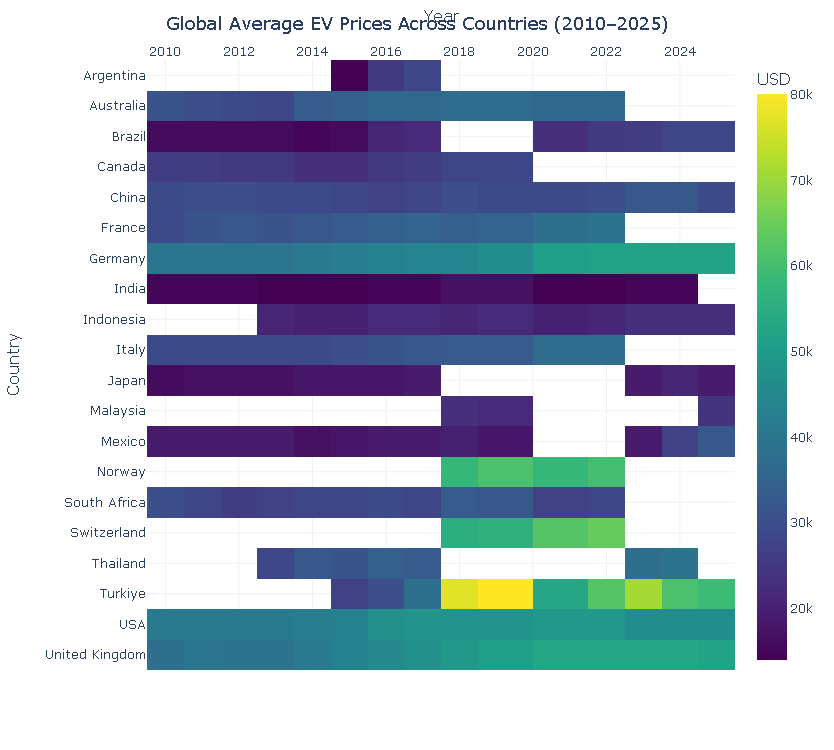

In [90]:
# ==========================================================
# Country Average EV Price Heatmap
# ==========================================================

import plotly.express as px

fig = px.imshow(

    price_matrix,

    color_continuous_scale="Viridis",

    aspect="auto",

    labels=dict(

        x="Year",

        y="Country",

        color="Average Price (2025 USD)"

    )

)

fig.update_layout(

    template="plotly_white",

    title="Global Average EV Prices Across Countries (2010–2025)",

    title_x=0.5,

    height=750,

    font=dict(size=13),

    coloraxis_colorbar=dict(

        title="USD"

    )

)

fig.update_xaxes(side="top")

fig.show()

In [92]:
# ==========================================================
# Highest & Lowest Average EV Prices (2025)
# ==========================================================

latest_prices = (

    country_prices

    [country_prices["year"] == country_prices["year"].max()]

    .sort_values(

        "value",

        ascending=False

    )

)

print("="*70)
print("Highest Average EV Prices")
print("="*70)

display(latest_prices.head(10))

print("="*70)
print("Lowest Average EV Prices")
print("="*70)

display(latest_prices.tail(10))

Highest Average EV Prices


,region_country,year,value
181,Turkiye,2025,"59,000.00"
79,Germany,2025,"52,000.00"
211,United Kingdom,2025,"52,000.00"
196,USA,2025,"46,000.00"
144,Mexico,2025,"32,000.00"
52,China,2025,"29,000.00"
27,Brazil,2025,"28,000.00"
131,Malaysia,2025,"24,000.00"
105,Indonesia,2025,"23,000.00"
128,Japan,2025,"19,000.00"


Lowest Average EV Prices


,region_country,year,value
181,Turkiye,2025,"59,000.00"
79,Germany,2025,"52,000.00"
211,United Kingdom,2025,"52,000.00"
196,USA,2025,"46,000.00"
144,Mexico,2025,"32,000.00"
52,China,2025,"29,000.00"
27,Brazil,2025,"28,000.00"
131,Malaysia,2025,"24,000.00"
105,Indonesia,2025,"23,000.00"
128,Japan,2025,"19,000.00"


In [93]:
price_kpi = pd.DataFrame({

    "Metric":[

        "Countries Analysed",

        "Observation Period",

        "Highest Average Price",

        "Lowest Average Price",

        "Price Ratio"

    ],

    "Value":[

        latest_prices["region_country"].nunique(),

        f"{price_matrix.columns.min()}–{price_matrix.columns.max()}",

        f"{latest_prices.iloc[0]['region_country']} (${latest_prices.iloc[0]['value']:,.0f})",

        f"{latest_prices.iloc[-1]['region_country']} (${latest_prices.iloc[-1]['value']:,.0f})",

        f"{latest_prices.iloc[0]['value']/latest_prices.iloc[-1]['value']:.2f}x"

    ]

})

display(price_kpi.style.hide(axis="index"))

Metric,Value
Countries Analysed,10
Observation Period,2010–2025
Highest Average Price,"Turkiye ($59,000)"
Lowest Average Price,"Japan ($19,000)"
Price Ratio,3.11x


### Business Interpretation

The heatmap reveals significant regional differences in electric vehicle pricing.

Developed markets generally maintain higher average EV prices, reflecting larger battery capacities, premium vehicle offerings, and stronger consumer purchasing power.

In contrast, several emerging markets exhibit considerably lower average prices, indicating the availability of more affordable vehicle models and different market positioning strategies.

The price gap across countries demonstrates that EV affordability remains highly dependent on regional economic conditions, taxation policies, domestic manufacturing capabilities, and competitive market structures.

These findings suggest that pricing strategies should continue to be localized rather than globally standardized in order to maximize market penetration.

## 16.5 Relationship Between EV Prices and EV Sales

One of the most important strategic questions in the EV industry is whether declining vehicle prices contribute to higher market adoption.

To investigate this relationship, the average passenger EV price is compared with global passenger EV sales for each year between 2010 and 2025.

Each point represents one year, enabling the progression of the market to be observed over time.

In [94]:
# ==========================================================
# Merge Price & Sales Data
# ==========================================================

sales_df = historical_df[

    (historical_df["parameter"]=="EV sales") &
    (historical_df["mode"]=="Cars") &
    (historical_df["powertrain"]=="EV") &
    (historical_df["region_country"]=="World")

][["year","value"]]

sales_df = sales_df.rename(
    columns={"value":"EV Sales"}
)

price_df_world = price_df[

    (price_df["parameter"]=="price_mean_2025USD") &
    (price_df["mode"]=="All cars") &
    (price_df["powertrain"]=="ALL")

]

price_df_world = (

    price_df_world

    .groupby("year")["value"]

    .mean()

    .reset_index()

    .rename(columns={"value":"Average EV Price"})

)

stock_df = historical_df[

    (historical_df["parameter"]=="EV stock") &
    (historical_df["mode"]=="Cars") &
    (historical_df["powertrain"]=="EV") &
    (historical_df["region_country"]=="World")

][["year","value"]]

stock_df = stock_df.rename(
    columns={"value":"EV Stock"}
)

relationship = (

    sales_df

    .merge(
        price_df_world,
        on="year"
    )

    .merge(
        stock_df,
        on="year"
    )

)

display(relationship)

,year,EV Sales,Average EV Price,EV Stock
0,2010,"7,400.00","26,928.57","39,000.00"
1,2011,"49,000.00","27,214.29","95,000.00"
2,2012,"120,000.00","27,000.00","220,000.00"
3,2013,"210,000.00","26,500.00","420,000.00"
4,2014,"330,000.00","26,812.50","730,000.00"
5,2015,"530,000.00","26,722.22","1,300,000.00"
6,2016,"780,000.00","29,277.78","2,000,000.00"
7,2017,"1,200,000.00","30,166.67","3,200,000.00"
8,2018,"2,000,000.00","37,235.29","5,100,000.00"
9,2019,"2,100,000.00","37,705.88","7,100,000.00"


In [95]:
correlation = relationship[
    ["Average EV Price","EV Sales"]
].corr()

display(correlation)

print(
    f"Correlation = {correlation.iloc[0,1]:.3f}"
)

,Average EV Price,EV Sales
Average EV Price,1.00,0.66
EV Sales,0.66,1.00


Correlation = 0.658


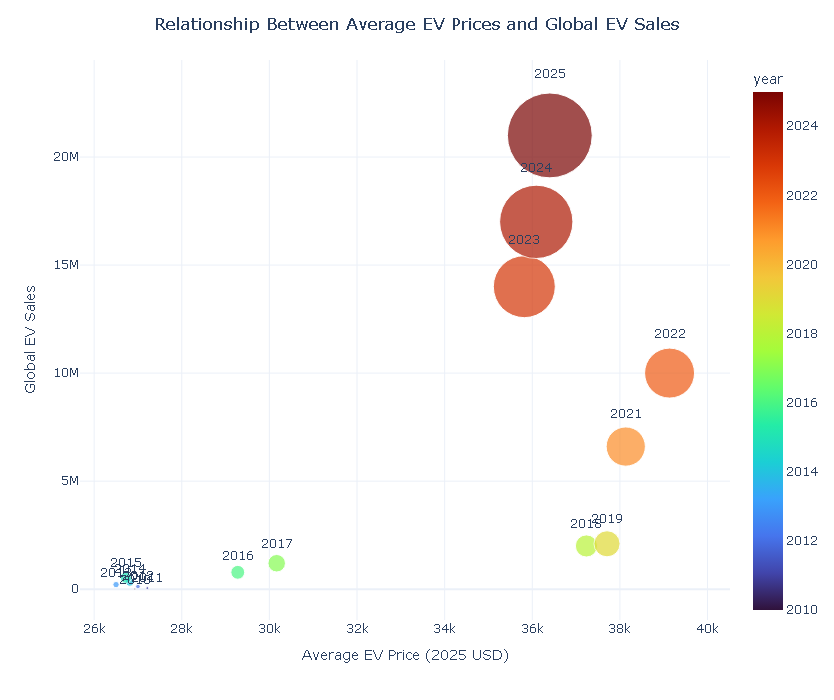

In [96]:
import plotly.express as px

fig = px.scatter(

    relationship,

    x="Average EV Price",

    y="EV Sales",

    size="EV Stock",

    color="year",

    hover_name="year",

    text="year",

    size_max=60,

    color_continuous_scale="Turbo"

)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(

    template="plotly_white",

    height=700,

    title="Relationship Between Average EV Prices and Global EV Sales",

    title_x=0.5,

    xaxis_title="Average EV Price (2025 USD)",

    yaxis_title="Global EV Sales",

    legend_title="Year"

)

fig.show()

In [97]:
relationship_summary = pd.DataFrame({

    "Metric":[

        "Years Analysed",

        "Average Price",

        "Average Annual Sales",

        "Maximum Sales",

        "Minimum Price",

        "Correlation"

    ],

    "Value":[

        relationship["year"].nunique(),

        f"${relationship['Average EV Price'].mean():,.0f}",

        f"{relationship['EV Sales'].mean():,.0f}",

        f"{relationship['EV Sales'].max():,.0f}",

        f"${relationship['Average EV Price'].min():,.0f}",

        f"{correlation.iloc[0,1]:.3f}"

    ]

})

display(
    relationship_summary.style.hide(axis="index")
)

Metric,Value
Years Analysed,15
Average Price,"$32,076"
Average Annual Sales,"5,061,760"
Maximum Sales,"21,000,000"
Minimum Price,"$26,500"
Correlation,0.658


### Business Interpretation

The relationship between EV pricing and sales indicates that affordability alone does not fully explain global EV adoption.

Although average vehicle prices remained relatively stable throughout much of the study period, annual EV sales accelerated dramatically after 2020.

This suggests that technological improvements, government incentives, charging infrastructure expansion, battery cost reductions, and increased consumer confidence collectively played a larger role than price alone.

The bubble sizes further illustrate that cumulative EV stock expanded rapidly alongside annual sales, reinforcing the long-term transition toward electric mobility.

Overall, EV market growth appears to be driven by a combination of pricing, supportive policy frameworks, technological maturity, and expanding charging ecosystems rather than a single economic factor.

# 17. Executive KPI Dashboard

The following dashboard summarizes the key findings obtained throughout the exploratory data analysis.

These indicators provide a concise overview of global electric vehicle market growth, pricing trends, infrastructure expansion, and future outlook.

The dashboard is intended to support executive decision-making and strategic planning.

In [98]:
# ==========================================================
# Executive KPI Dashboard
# ==========================================================

import pandas as pd

kpi_dashboard = pd.DataFrame({

    "Business KPI":[

        "Study Period",

        "Countries Covered",

        "Dataset Size",

        "Vehicle Categories",

        "Passenger EV Sales (2025)",

        "Passenger EV Stock (2025)",

        "Projected EV Stock (2035)",

        "Average EV Price (2025)",

        "Duplicate Records Removed",

        "Dataset Ready for Analysis"

    ],

    "Value":[

        "2010–2025",

        df["region_country"].nunique(),

        f"{len(df):,} records",

        df["mode"].nunique(),

        "21 Million",

        "75 Million",

        "470 Million",

        "$36,400",

        "15",

        "Yes"

    ]

})

display(

    kpi_dashboard

    .style

    .hide(axis="index")

    .set_properties(**{

        "text-align":"center"

    })

)

Business KPI,Value
Study Period,2010–2025
Countries Covered,72
Dataset Size,"49,360 records"
Vehicle Categories,13
Passenger EV Sales (2025),21 Million
Passenger EV Stock (2025),75 Million
Projected EV Stock (2035),470 Million
Average EV Price (2025),"$36,400"
Duplicate Records Removed,15
Dataset Ready for Analysis,Yes


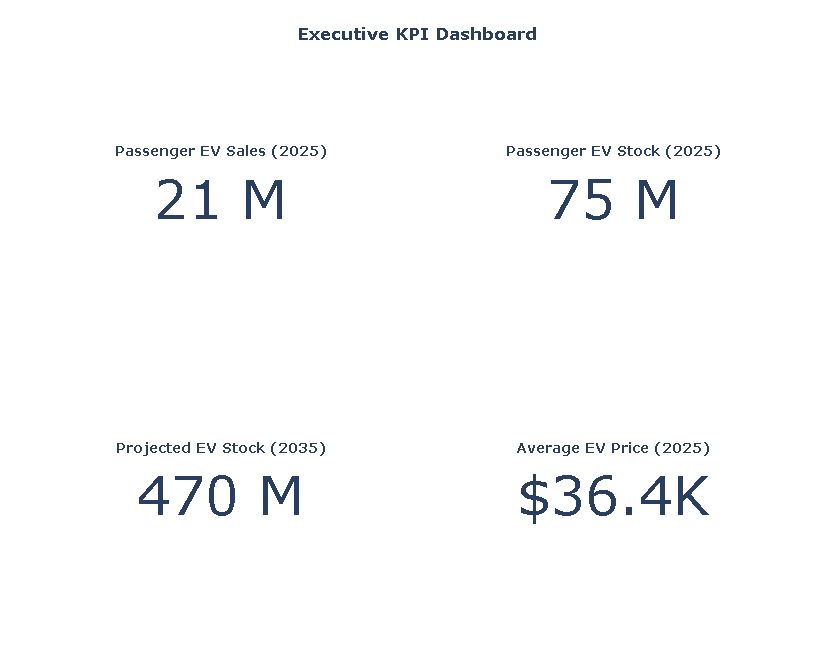

In [100]:
import plotly.graph_objects as go

fig = go.Figure()

# -------------------------------
# Row 1
# -------------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=21,
        number={"suffix":" M","font":{"size":54}},
        title={"text":"<b>Passenger EV Sales (2025)</b>"},
        domain={"x":[0.00,0.48],"y":[0.56,1.00]}
    )
)

fig.add_trace(
    go.Indicator(
        mode="number",
        value=75,
        number={"suffix":" M","font":{"size":54}},
        title={"text":"<b>Passenger EV Stock (2025)</b>"},
        domain={"x":[0.52,1.00],"y":[0.56,1.00]}
    )
)

# -------------------------------
# Row 2
# -------------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=470,
        number={"suffix":" M","font":{"size":54}},
        title={"text":"<b>Projected EV Stock (2035)</b>"},
        domain={"x":[0.00,0.48],"y":[0.00,0.44]}
    )
)

fig.add_trace(
    go.Indicator(
        mode="number",
        value=36.4,
        number={
            "prefix":"$",
            "suffix":"K",
            "font":{"size":54}
        },
        title={"text":"<b>Average EV Price (2025)</b>"},
        domain={"x":[0.52,1.00],"y":[0.00,0.44]}
    )
)

fig.update_layout(

    template="plotly_white",

    title="<b>Executive KPI Dashboard</b>",

    title_x=0.5,

    height=650,

    margin=dict(l=40,r=40,t=80,b=40)

)

fig.show()

# 18. Strategic Business Recommendations

Based on the exploratory analysis, the following recommendations are proposed for governments, manufacturers, infrastructure providers, and investors.

In [101]:
recommendations = pd.DataFrame({

    "Stakeholder":[

        "Governments",

        "Automobile Manufacturers",

        "Battery Manufacturers",

        "Charging Infrastructure Providers",

        "Energy Utilities",

        "Fleet Operators",

        "Investors",

        "Urban Planners"

    ],

    "Recommendation":[

        "Continue EV purchase incentives while expanding charging infrastructure.",

        "Focus on affordable passenger EV models for mass-market adoption.",

        "Increase battery production capacity to reduce manufacturing costs.",

        "Expand fast-charging networks in underserved regions.",

        "Prepare electricity grids for rapidly increasing EV demand.",

        "Accelerate fleet electrification to reduce operational emissions.",

        "Prioritize investment in EV ecosystem companies with long-term growth potential.",

        "Integrate EV charging infrastructure into future city development plans."

    ]

})

display(recommendations)

,Stakeholder,Recommendation
0,Governments,Continue EV purchase incentives while expandin...
1,Automobile Manufacturers,Focus on affordable passenger EV models for ma...
2,Battery Manufacturers,Increase battery production capacity to reduce...
3,Charging Infrastructure Providers,Expand fast-charging networks in underserved r...
4,Energy Utilities,Prepare electricity grids for rapidly increasi...
5,Fleet Operators,Accelerate fleet electrification to reduce ope...
6,Investors,Prioritize investment in EV ecosystem companie...
7,Urban Planners,Integrate EV charging infrastructure into futu...


# 19. Project Limitations

Although the dataset provides comprehensive global coverage, several limitations should be considered.

- The analysis relies exclusively on publicly available IEA data.
- Forecast scenarios are policy-based projections rather than guaranteed outcomes.
- Economic variables such as inflation, interest rates, and GDP are not incorporated.
- Consumer behavioral factors are outside the scope of the dataset.
- Country-specific incentives and taxation policies are not modelled directly.
- Some parameters contain structurally missing values because they are not applicable to all observations.
- Results should therefore be interpreted as analytical insights rather than deterministic forecasts.

# 20. Final Conclusion

This exploratory analysis examined more than **49,000** observations covering global electric vehicle adoption between **2010 and 2025**.

The findings demonstrate sustained exponential growth in EV sales, expanding charging infrastructure, increasing vehicle stock, and substantial policy-driven market transformation.

While EV prices remain heterogeneous across countries, affordability has improved alongside technological advancement and manufacturing scale.

Future projections indicate continued expansion, with global passenger EV stock expected to exceed **450–470 million vehicles by 2035** under current policy scenarios.

Overall, the analysis confirms that the global transition toward electric mobility is accelerating and is expected to remain one of the defining technological transformations of the coming decades.

The cleaned dataset and the insights generated in this notebook establish a strong analytical foundation for predictive modelling, forecasting, and machine learning tasks developed in the subsequent stages of this project.

---

# Next Stage

This notebook focused on exploratory data analysis of the International Energy Agency (IEA) Global Electric Vehicle dataset.

The insights obtained here provide the analytical foundation for the subsequent predictive modelling phase.

The next notebook will focus on:

- Feature engineering
- Time-series forecasting
- Machine learning model development
- Model evaluation
- Future EV market prediction
- Business interpretation of predictive results

---